### Redes neuronales - Clasificación


In [30]:
#Bloque de imports:

import numpy as np
import pandas as pd
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from keras.utils import to_categorical
from keras.layers import BatchNormalization
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import KFold, train_test_split

plt.rcParams['figure.figsize'] = [3, 3]

In [31]:
#Bloque de funciones:


# Cargar dataset y dividir en train / test
def cargar_dataset():
    dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
    datos = dataset[:, :512].astype('float32')
    etiquetas = np.array([
        {'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[etiqueta.strip()]
        for etiqueta in dataset[:, 512]
    ])

    trainX, testX, trainY, testY = train_test_split(
        datos,
        etiquetas,
        test_size=0.1,
        random_state=1,
        stratify=etiquetas
    )

    trainY = to_categorical(trainY, num_classes=5)
    testY = to_categorical(testY, num_classes=5)
    return trainX, trainY, testX, testY

# Normalización de tonos de pixel
def prep_pixels(train, test):
    train_norm = train.astype('float32') / 255.0
    test_norm = test.astype('float32') / 255.0
    return train_norm, test_norm


def enriquecer_features(datos):
    bytes_originales = np.clip(np.rint(datos * 255), 0, 255).astype('uint8')

    # 0. Header exacto (primeros 32 bytes normalizados)
    header_32 = datos[:, :32]
    
    # 1. Histograma global
    histogramas = np.array([np.bincount(f, minlength=256) / 512.0 for f in bytes_originales])
    
    # 2. Estadísticas
    estadisticas = np.column_stack([
        bytes_originales.mean(axis=1) / 255.0,
        bytes_originales.std(axis=1) / 255.0,
        bytes_originales.min(axis=1) / 255.0,
        bytes_originales.max(axis=1) / 255.0
    ])
    
    # 3. Histogramas por bloques
    bloques = bytes_originales.reshape(-1, 8, 64)
    histogramas_bloques = np.array([
        np.concatenate([np.bincount(b, minlength=256) / 64.0 for b in m])
        for m in bloques
    ])

    # 4. Transiciones 
    bytes_reducidos = bytes_originales // 16
    transiciones = bytes_reducidos[:, :-1] * 16 + bytes_reducidos[:, 1:]
    histogramas_transiciones = np.array([np.bincount(f, minlength=256) / 511.0 for f in transiciones])

    # 5. Entropía
    entropia = -np.sum(histogramas * np.log2(histogramas + 1e-9), axis=1, keepdims=True)

    # 6. Histograma de Diferencias Absolutas
    bytes_int = bytes_originales.astype('int16')
    diferencias = np.abs(bytes_int[:, 1:] - bytes_int[:, :-1]).astype('uint8')
    histogramas_diff = np.array([np.bincount(f, minlength=256) / 511.0 for f in diferencias])

	# 7. Transformada de Fourier (Espectro de Frecuencias)
    # RFFT devuelve 257 magnitudes de frecuencia para 512 bytes
    fft_magnitudes = np.abs(np.fft.rfft(datos, axis=1)) / 512.0

    return np.concatenate([
        header_32,                # 32
        histogramas,              # 256
        estadisticas,             # 4
        histogramas_bloques,      # 2048
        histogramas_transiciones, # 256
        entropia,                 # 1
        histogramas_diff,          # 256
		fft_magnitudes            # 257
    ], axis=1)                    # TOTAL = 3110 características


# Graficar un fragmento de bytes
def graficar_uno(valor, conjunto, prediccion=None):
    plt.figure()
    plt.plot(conjunto[valor][:512])
    if prediccion is not None:
        plt.ylabel('Predicho: '+str(prediccion))
    return plt.show()

def predecir_con_ensamble(dataX, dataY, test_features_final, epocas=150):
    # Usamos 10 divisiones para el mega-ensamble
    kfold = KFold(n_splits=10, shuffle=True, random_state=1)
    
    # Matriz para sumar las probabilidades de las 500 imágenes del test ciego
    probas_totales = np.zeros((len(test_features_final), 5))
    
    # Pesos de clase para forzar a la red a enfocarse en PNG y WEBP
    pesos_clases = {0: 1.0, 1: 1.5, 2: 3.0, 3: 1.0, 4: 3.0}
    
    fold_actual = 1
    for train_ix, val_ix in kfold.split(dataX):
        print(f"--- Entrenando Fold {fold_actual} de 10 ---")
        
        tX, vX = dataX[train_ix], dataX[val_ix]
        tY, vY = dataY[train_ix], dataY[val_ix]
        
        modelo = definir_modelo()
        modelo.fit(
            tX, tY, 
            epochs=epocas, 
            batch_size=32, 
            validation_data=(vX, vY),
            callbacks=[early_stop, reduce_lr], 
            class_weight=pesos_clases,  
            verbose=0 
        )
        
        probas_totales += modelo.predict(test_features_final, verbose=0)
        fold_actual += 1

    # Promediamos las probabilidades de los 10 modelos
    probas_promedio = probas_totales / 10.0
    
    clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
    predicciones_ensamble = [clases[i] for i in np.argmax(probas_promedio, axis=1)]
    
    return predicciones_ensamble

In [10]:
# Evaluador SIMPLE

def evaluar_modelo_simple(dataX,dataY,modelo,estadoaleatorio=1,epocas=10):
	scores, histories= list(),list()
	model = modelo()
	history = model.fit(trainX, trainY, epochs=epocas, batch_size=32, validation_data=(testX, testY), verbose=1)
	_, acc = model.evaluate(testX, testY, verbose=1)
	print('> %.3f' % (acc * 100.0))
	scores.append(acc)
	histories.append(history)
	return scores, histories, model

# Evaluación con k-fold cross-validation
def evaluar_modelo_kfold(dataX, dataY, modelo, n_folds=5, estadoaleatorio=1):
	scores, histories = list(), list()
	# preparar los k-fold
	kfold = KFold(n_folds, shuffle=True, random_state=estadoaleatorio)
	# Enumerar las divisiones
	for train_ix, test_ix in kfold.split(dataX):
		# definir model
		model = modelo()
		# elegir filas para train y validation
		trainX, trainY, testX, testY = dataX[train_ix], dataY[train_ix], dataX[test_ix], dataY[test_ix]
		# fitear modelo
		history = model.fit(trainX, trainY, epochs=10, batch_size=32, validation_data=(testX, testY), verbose=0)
		# evaluar modelo
		_, acc = model.evaluate(testX, testY, verbose=0)
		print('> %.3f' % (acc * 100.0))
		# guardar puntajes
		scores.append(acc)
		histories.append(history)
	return scores, histories, model

# Graficar diagnósticos
def diagnosticos(histories):
	for i in range(len(histories)):
		# graficar loss
		plt.subplot(2, 1, 1)
		plt.title('Cross Entropy Loss')
		plt.plot(histories[i].history['loss'], color='blue', label='train')
		plt.plot(histories[i].history['val_loss'], color='orange', label='test')
		# graficar accuracy
		plt.subplot(2, 1, 2)
		plt.title('Classification Accuracy')
		plt.plot(histories[i].history['accuracy'], color='blue', label='train')
		plt.plot(histories[i].history['val_accuracy'], color='orange', label='test')
	plt.show()

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Carga normal y enriquecimiento a 3078 features
trainX, trainY, testX, testY = cargar_dataset()
trainX, testX = prep_pixels(trainX, testX)

print("Enriqueciendo características...")
trainX_completos = enriquecer_features(trainX)
testX_completos = enriquecer_features(testX)

# 2. Poda de Características con Random Forest (Nos quedamos con el Top 800)
print("Aplicando Poda de Características (Random Forest)...")
etiquetas_simples = np.argmax(trainY, axis=1) # Pasamos one-hot a numéricas
bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque.fit(trainX_completos, etiquetas_simples)

# Seleccionamos los índices de las 800 columnas más importantes
CANTIDAD_TOP = 800
indices_top = np.argsort(bosque.feature_importances_)[::-1][:CANTIDAD_TOP]

trainX_podados = trainX_completos[:, indices_top]
testX_podados = testX_completos[:, indices_top]

# 3. Escalado estadístico (StandardScaler)
print("Escalando características podadas...")
scaler = StandardScaler()
trainX = scaler.fit_transform(trainX_podados)
testX = scaler.transform(testX_podados)

print(f"Dimensiones FINALES listas para la red -> trainX: {trainX.shape}, testX: {testX.shape}")

Enriqueciendo características...
Aplicando Poda de Características (Random Forest)...
Escalando características podadas...
Dimensiones FINALES listas para la red -> trainX: (3600, 800), testX: (400, 800)


In [33]:
def cargar_dataset_completo():
    dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
    datos = dataset[:, :512].astype('float32') / 255.0
    
    etiquetas_txt = np.array([etiqueta.strip() for etiqueta in dataset[:, 512]])
    etiquetas_num = np.array([
        {'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e]
        for e in etiquetas_txt
    ])
    etiquetas_onehot = to_categorical(etiquetas_num, num_classes=5)
    
    print("Enriqueciendo dataset completo...")
    datos_completos = enriquecer_features(datos)
    
    print("Aplicando Poda al dataset completo...")
    bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    bosque.fit(datos_completos, etiquetas_num)
    
    indices_top_final = np.argsort(bosque.feature_importances_)[::-1][:800]
    datos_podados = datos_completos[:, indices_top_final]
    
    print("Escalando dataset completo...")
    scaler_final = StandardScaler()
    datos_finales = scaler_final.fit_transform(datos_podados)
    
    return datos_finales, etiquetas_onehot, indices_top_final, scaler_final

def entrenar_modelo_completo(epocas):
    # Desempaquetamos los 4 valores generados
    datos, etiquetas, indices_top_final, scaler_final = cargar_dataset_completo()
    
    modelo_final = definir_modelo()
    modelo_final.fit(
        datos,
        etiquetas,
        epochs=epocas,
        batch_size=32,
        verbose=1
    )
    # Devolvemos el modelo junto con las reglas de recorte y escalado
    return modelo_final, indices_top_final, scaler_final


def predecirparaunalista(redneuronalentrenada,conjunto=None):
    if conjunto is None:
        conjunto = testX
    puntajes = redneuronalentrenada.predict(conjunto)
    prediccion = np.zeros(len(conjunto), dtype=int)
    for x in range(len(conjunto)):
        prediccion[x] = np.argmax(puntajes[x])
    unique, counts = np.unique(prediccion,return_counts=True)
    return dict(zip(unique,counts))

def matrizdeconfusion(redneuronalentrenada,conjunto=None, targetsonehot=None, normalizar=False):
    if conjunto is None:
        conjunto = testX
    if targetsonehot is None:
        targetsonehot = testY

    puntajes = redneuronalentrenada.predict(conjunto, verbose=0)
    prediccion = np.argmax(puntajes, axis=1)
    objetivo = np.argmax(targetsonehot, axis=1)
    etiquetas = ['gif', 'jpg', 'png', 'qoi', 'webp']

    matriz = confusion_matrix(
        objetivo,
        prediccion,
        normalize='true' if normalizar else None
    )
    display = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=etiquetas
    )
    display.plot(cmap='Blues', values_format='.2f' if normalizar else 'd')
    plt.title('Matriz de confusión')
    plt.show()


def find_non_equal_indices(list1, list2):
    non_equal_indices = []
    for i in range(min(len(list1), len(list2))):
        if list1[i] != list2[i]:
            non_equal_indices.append(i)
    return non_equal_indices

def listarerrores(adivinado,objetivo=testY):
    errores = find_non_equal_indices(adivinado,np.argmax(objetivo, axis = 1))
    return errores

In [13]:
print ("Tamaño de conjunto de entrenamiento: "+str(len(trainX)) + "\n"+"Tamaño de conjunto de test:          "+str(len(testX)))

Tamaño de conjunto de entrenamiento: 3600
Tamaño de conjunto de test:          400


In [14]:
plt.rcParams['figure.figsize'] = [3, 3]

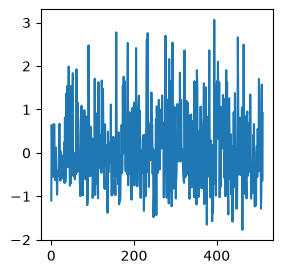

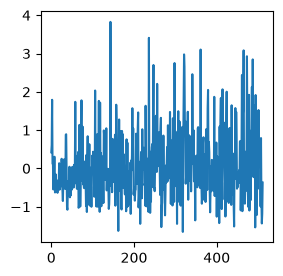

In [15]:
graficar_uno(315, trainX)
graficar_uno(100, testX)

In [16]:
# Modelo feedforward para clasificación

def definir_modelo():
    modelo = Sequential([
        keras.Input(shape=(800,)),
        Dense(448, activation='swish'),
        BatchNormalization(),
        Dropout(0.30000000000000004),
        Dense(64, activation='swish'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(5, activation='softmax')
    ])

    modelo.compile(
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        optimizer=keras.optimizers.AdamW(learning_rate=0.0001, weight_decay=0.004),
        metrics=['accuracy']
    )
    return modelo

In [17]:
modelo_entrenado = definir_modelo()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=0.00001
)

# Ahora trainX y la red miden 800. ¡No va a dar error!
history = modelo_entrenado.fit(
    trainX,
    trainY,
    epochs=150,
    batch_size=32,
    validation_data=(testX, testY),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

loss, accuracy = modelo_entrenado.evaluate(testX, testY, verbose=0)
print(f'Accuracy de validación: {accuracy * 100:.2f}%')
print("Épocas ejecutadas:", len(history.history["loss"]))
print("Mejor época por val_loss:", np.argmin(history.history["val_loss"]) + 1)
print("Mejor época por val_accuracy:", np.argmax(history.history["val_accuracy"]) + 1)


Epoch 1/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4842 - loss: 1.6001 - val_accuracy: 0.6875 - val_loss: 1.0082 - learning_rate: 1.0000e-04
Epoch 2/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6572 - loss: 1.1363 - val_accuracy: 0.7575 - val_loss: 0.8773 - learning_rate: 1.0000e-04
Epoch 3/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7097 - loss: 0.9913 - val_accuracy: 0.8225 - val_loss: 0.7999 - learning_rate: 1.0000e-04
Epoch 4/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7803 - loss: 0.8796 - val_accuracy: 0.8475 - val_loss: 0.7502 - learning_rate: 1.0000e-04
Epoch 5/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8058 - loss: 0.8231 - val_accuracy: 0.8600 - val_loss: 0.7139 - learning_rate: 1.0000e-04
Epoch 6/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8308 - loss: 0.7851 - val_accuracy: 0.8725 - val_loss: 0.6846 - learning_rate: 1.0000e-04
Epoch 7/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc

In [18]:
# Evaluación en test_publico.csv
publico = np.loadtxt('../dataset/test_publico.csv', delimiter=',', dtype=str)
publicoX = publico[:, :512].astype('float32') / 255.0
publicoX = enriquecer_features(publicoX)
publicoY = np.array([
    {'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[etiqueta.strip()]
    for etiqueta in publico[:, 512]
])
publicoY = to_categorical(publicoY, num_classes=5)

publico_loss, publico_accuracy = modelo_entrenado.evaluate(
    publicoX,
    publicoY,
    verbose=0
)
print(f'Accuracy en test_publico: {publico_accuracy * 100:.2f}%')

print("Mejor train:", max(history.history["accuracy"]) * 100)
print("Mejor validación:", max(history.history["val_accuracy"]) * 100)
print("Test público:", publico_accuracy * 100)

InvalidArgumentError: Graph execution error:

Detected at node StatefulPartitionedCall/sequential_50_1/dense_150_1/BiasAdd defined at (most recent call last):
<stack traces unavailable>
Matrix size-incompatible: In[0]: [32,3110], In[1]: [800,448]
	 [[{{node StatefulPartitionedCall/sequential_50_1/dense_150_1/BiasAdd}}]] [Op:__inference_multi_step_on_iterator_2625968]

In [ ]:
# Entrenamiento final con las 4000 muestras etiquetadas
epocas_finales = np.argmax(history.history['val_accuracy']) + 1
modelo_final = entrenar_modelo_completo(epocas_finales)

final_publico_loss, final_publico_accuracy = modelo_final.evaluate(
    publicoX,
    publicoY,
    verbose=0
)
print(f'Accuracy del modelo final en test_publico: {final_publico_accuracy * 100:.2f}%')

Enriqueciendo dataset completo...
Aplicando Poda al dataset completo...
Escalando dataset completo...
Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4897 - loss: 1.5431
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6455 - loss: 1.1353
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7243 - loss: 0.9741
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7760 - loss: 0.8832
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7960 - loss: 0.8352
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8390 - loss: 0.7706
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8595 - loss: 0.7376
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8717 - loss: 0.7082
Epoch 9/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8835 - loss: 0.6943
Epoch 10/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9097 - loss: 0.6537
Epoch 11/30
125/125 ━━━━━━━━━━━━━━━━━

AttributeError: 'tuple' object has no attribute 'evaluate'

In [ ]:
import numpy as np
from keras.utils import to_categorical

# Cargar el test público
publico = np.loadtxt('../dataset/test_publico.csv', delimiter=',', dtype=str)
publico_bytes = publico[:, :512].astype('float32') / 255.0

# Extraer etiquetas y pasar a one-hot
publicoY = np.array([
    {'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[etiqueta.strip()]
    for etiqueta in publico[:, 512]
])
publicoY = to_categorical(publicoY, num_classes=5)

# Enriquecer, Podar y Escalar
print("Enriqueciendo test público...")
publico_features_comp = enriquecer_features(publico_bytes)

print("Aplicando poda y escalado usando reglas del entrenamiento...")
publicoX_podado = publico_features_comp[:, indices_top]
publicoX = scaler.transform(publicoX_podado)

# Evaluar
loss_pub, acc_pub = modelo_entrenado.evaluate(publicoX, publicoY, verbose=0)
print(f'---> BOOM! Accuracy en TEST PÚBLICO: {acc_pub * 100:.2f}% <---')

Enriqueciendo test público...
Aplicando poda y escalado usando reglas del entrenamiento...
---> BOOM! Accuracy en TEST PÚBLICO: 86.80% <---


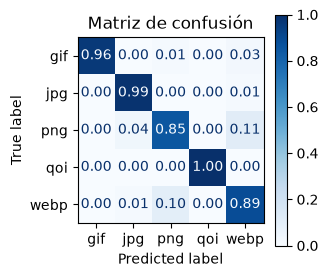

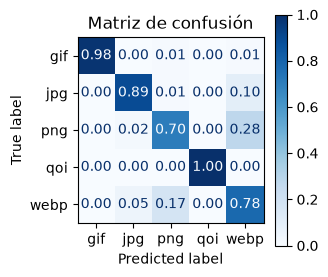

In [ ]:
# Matriz de confusión sobre el conjunto de validación
matrizdeconfusion(modelo_entrenado, testX, testY, normalizar=True)

matrizdeconfusion(modelo_entrenado, publicoX,publicoY, normalizar=True)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from keras.utils import to_categorical
from tensorflow import keras

# 1. Cargar el 100% de los datos etiquetados (4000 muestras de train)
dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
trainX_crudo = dataset[:, :512].astype('float32') / 255.0
trainY_txt = np.array([e.strip() for e in dataset[:, 512]])
trainY_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e] for e in trainY_txt])
trainY_onehot = to_categorical(trainY_num, num_classes=5)

# 2. Cargar el Test Público (500 muestras)
publico = np.loadtxt('../dataset/test_publico.csv', delimiter=',', dtype=str)
publicoX_crudo = publico[:, :512].astype('float32') / 255.0
publicoY_txt = np.array([e.strip() for e in publico[:, 512]])
publicoY_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e] for e in publicoY_txt])
publicoY_onehot = to_categorical(publicoY_num, num_classes=5)

# 3. Enriquecer, Podar y Escalar todo junto
print("Enriqueciendo datos a 3078 features...")
train_feat_comp = enriquecer_features(trainX_crudo)
publico_feat_comp = enriquecer_features(publicoX_crudo)

print("Aplicando poda (Random Forest)...")
bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque.fit(train_feat_comp, trainY_num)
indices_finales = np.argsort(bosque.feature_importances_)[::-1][:800]

print("Escalando datos...")
scaler_final = StandardScaler()
trainX_final = scaler_final.fit_transform(train_feat_comp[:, indices_finales])
publicoX_final = scaler_final.transform(publico_feat_comp[:, indices_finales])

# 4. K-Fold Ensamble sobre el Test Público
print("Entrenando Ensamble de 10 Folds para evaluar...")
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
probas_totales = np.zeros((len(publicoX_final), 5))

# Pesos para controlar el sesgo entre PNG y WEBP
pesos_clases = {0: 1.0, 1: 1.5, 2: 3.0, 3: 1.0, 4: 3.0} 

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

fold_actual = 1
for train_ix, val_ix in kfold.split(trainX_final):
    print(f"   --- Fold {fold_actual}/10 ---")
    tX, vX = trainX_final[train_ix], trainX_final[val_ix]
    tY, vY = trainY_onehot[train_ix], trainY_onehot[val_ix]
    
    # Asegurate de que definir_modelo() tiene Input(shape=(800,))
    modelo = definir_modelo()
    modelo.fit(tX, tY, epochs=150, batch_size=32, validation_data=(vX, vY),
               callbacks=[early_stop, reduce_lr], class_weight=pesos_clases, verbose=0)
    
    # Sumar probabilidades para el test público
    probas_totales += modelo.predict(publicoX_final, verbose=0)
    fold_actual += 1

# 5. Métricas y Gráfico de Matriz de Confusión
probas_promedio = probas_totales / 10.0
predicciones_indices = np.argmax(probas_promedio, axis=1)

acc_ensamble = accuracy_score(publicoY_num, predicciones_indices)
print(f"\n---> ACCURACY FINAL DEL ENSAMBLE EN TEST PÚBLICO: {acc_ensamble * 100:.2f}% <---")

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
cm = confusion_matrix(publicoY_num, predicciones_indices, normalize='true')

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title(f'Matriz de Confusión Ensamble Público\n(Accuracy: {acc_ensamble * 100:.2f}%)')
plt.show()

Enriqueciendo datos a 3078 features...
Aplicando poda (Random Forest)...
Escalando datos...
Entrenando Ensamble de 10 Folds para evaluar...
   --- Fold 1/10 ---


KeyboardInterrupt: 

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# 1. Calculamos los pesos base balanceados (lo que ya tenías)
etiquetas_numericas = np.argmax(etiquetas_train, axis=1)
pesos_array = compute_class_weight('balanced', classes=np.unique(etiquetas_numericas), y=etiquetas_numericas)
pesos_modificados = dict(enumerate(pesos_array))

print("Pesos originales (Balanceados por Sklearn):")
print(pesos_modificados)

# 2. INTERVENCIÓN MANUAL (El hack táctico)
# Multiplicamos el peso del PNG (2) para que equivocarse acá dispare el error al cielo
pesos_modificados[2] = pesos_modificados[2] * 2.5 

# Le damos una ayuda al JPG (1) para recuperar ese 23% que le estaba robando el WEBP
pesos_modificados[1] = pesos_modificados[1] * 1.5 

# Planchamos el peso del WEBP (4) para que la red deje de usarlo de comodín
pesos_modificados[4] = pesos_modificados[4] * 0.5 

# El GIF (0) y QOI (3) los dejamos intactos porque ya tienen un 98% y 100% de acierto

print("\nPesos modificados a mano (Anti-WEBP):")
print(pesos_modificados)

NameError: name 'etiquetas_train' is not defined

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

def evaluar_ensamble_publico(dataX, dataY, publicoX, publicoY, epocas=150):
    # K-Fold con 10 divisiones para el mega-ensamble
    kfold = KFold(n_splits=10, shuffle=True, random_state=1)
    
    # Matriz para sumar las probabilidades del conjunto público
    probas_totales = np.zeros((len(publicoX), 5))
    
    # Pesos de clase para forzar a la red a enfocarse en las clases difíciles (PNG y WEBP)
    pesos_clases = {0: 1.0, 1: 1.5, 2: 3.0, 3: 1.0, 4: 3.0}
    
    fold_actual = 1
    for train_ix, val_ix in kfold.split(dataX):
        print(f"--- Entrenando Fold {fold_actual} de 10 ---")
        tX, vX = dataX[train_ix], dataX[val_ix]
        tY, vY = dataY[train_ix], dataY[val_ix]
        
        modelo = definir_modelo()
        modelo.fit(
            tX, tY, 
            epochs=epocas, 
            batch_size=32, 
            validation_data=(vX, vY),
            callbacks=[early_stop, reduce_lr], 
            class_weight=pesos_clases,
            verbose=0 
        )
        
        # Cada modelo suma sus probabilidades sobre el conjunto público
        probas_totales += modelo.predict(publicoX, verbose=0)
        fold_actual += 1

    # Promediamos las probabilidades de los 10 modelos
    probas_promedio = probas_totales / 10.0
    
    # Obtenemos las clases predichas
    predicciones = np.argmax(probas_promedio, axis=1)
    
    # Extraemos las clases reales (pasamos de one-hot a índices)
    reales = np.argmax(publicoY, axis=1)
    
    # Calculamos y mostramos la precisión final del ensamble
    accuracy_ensamble = accuracy_score(reales, predicciones)
    print(f"\n---> Accuracy final del Ensamble en test_publico: {accuracy_ensamble * 100:.2f}% <---")
    
    return probas_promedio

def predecir_con_ensamble(dataX, dataY, test_features_final, epocas=150):
    kfold = KFold(n_splits=10, shuffle=True, random_state=1)
    probas_totales = np.zeros((len(test_features_final), 5))
    
    # Índices: 'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4
    pesos_clases = {0: 1.0, 1: 1.5, 2: 3.0, 3: 1.0, 4: 3.0}
    
    fold_actual = 1
    for train_ix, val_ix in kfold.split(dataX):
        print(f"--- Entrenando Fold {fold_actual} de 10 ---")
        tX, vX = dataX[train_ix], dataX[val_ix]
        tY, vY = dataY[train_ix], dataY[val_ix]
        
        modelo = definir_modelo()
        modelo.fit(
            tX, tY, 
            epochs=epocas, 
            batch_size=32, 
            validation_data=(vX, vY),
            callbacks=[early_stop, reduce_lr], 
            class_weight=pesos_clases,  # <-- NUEVO: Forzamos el enfoque en las clases difíciles
            verbose=0 
        )
        
        probas_totales += modelo.predict(test_features_final, verbose=0)
        fold_actual += 1

    probas_promedio = probas_totales / 10.0
    clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
    return [clases[i] for i in np.argmax(probas_promedio, axis=1)]

In [ ]:
# 1. Cargamos y preprocesamos (Poda + Scaler) las 4000 muestras usando TU función
trainX_base, trainY_base, indices_top_final, scaler_final = cargar_dataset_completo()

# 2. Cargar test ciego crudo
ciego_crudo = np.loadtxt('../dataset/clasificacion_test_features.csv', delimiter=',', dtype='float32') / 255.0

# 3. Enriquecer, podar y escalar el test ciego usando las reglas que salieron de tu función
ciego_feat_comp = enriquecer_features(ciego_crudo)
ciegoX_base = scaler_final.transform(ciego_feat_comp[:, indices_top_final])

print(f"Dimensiones Base -> Train: {trainX_base.shape}, Ciego: {ciegoX_base.shape}")

Enriqueciendo dataset completo...
Aplicando Poda al dataset completo...
Escalando dataset completo...
Dimensiones Base -> Train: (4000, 800), Ciego: (500, 800)


In [ ]:
from sklearn.model_selection import KFold

print("--- FASE 1: ENTRENANDO MODELO INICIAL PARA PSEUDO-LABELING ---")
kfold_inicial = KFold(n_splits=5, shuffle=True, random_state=1)
probas_ciego = np.zeros((len(ciegoX_base), 5))

pesos_clases = {0: 1.0, 1: 1.5, 2: 3.0, 3: 1.0, 4: 3.0} 
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

fold_init = 1
for train_ix, val_ix in kfold_inicial.split(trainX_base):
    print(f"   Generando Base - Fold {fold_init}/5...")
    tX, vX = trainX_base[train_ix], trainX_base[val_ix]
    tY, vY = trainY_base[train_ix], trainY_base[val_ix]
    
    modelo_base = definir_modelo()
    modelo_base.fit(tX, tY, epochs=150, batch_size=32, validation_data=(vX, vY),
               callbacks=[early_stop, reduce_lr], class_weight=pesos_clases, verbose=0)
    probas_ciego += modelo_base.predict(ciegoX_base, verbose=0)
    fold_init += 1

probas_ciego /= 5.0

# Filtrar alta confianza (Mayor al 95%)
UMBRAL = 0.95
confianza_maxima = np.max(probas_ciego, axis=1)
indices_seguros = np.where(confianza_maxima >= UMBRAL)[0]

# Extraemos las imágenes ciegas en las que estamos seguros
pseudo_X = ciegoX_base[indices_seguros]
pseudo_Y_num = np.argmax(probas_ciego[indices_seguros], axis=1)
pseudo_Y = to_categorical(pseudo_Y_num, num_classes=5)

print(f"\n¡ÉXITO! Se encontraron {len(indices_seguros)} muestras ciegas con confianza >= {UMBRAL*100}%")

# Fusionamos el dataset original con las nuevas Pseudo-Labels
trainX_expandido = np.vstack([trainX_base, pseudo_X])
trainY_expandido = np.vstack([trainY_base, pseudo_Y])
print(f"Nuevo tamaño del dataset de entrenamiento: {len(trainX_expandido)} muestras.")

--- FASE 1: ENTRENANDO MODELO INICIAL PARA PSEUDO-LABELING ---


NameError: name 'ciegoX_base' is not defined

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("--- FASE 2: ENTRENAMIENTO FINAL Y EVALUACIÓN EN TEST PÚBLICO ---")
kfold_final = KFold(n_splits=10, shuffle=True, random_state=42)
probas_totales_publico = np.zeros((len(publicoX_base), 5))

fold_actual = 1
for train_ix, val_ix in kfold_final.split(trainX_expandido):
    print(f"   --- Fold Final {fold_actual}/10 ---")
    tX, vX = trainX_expandido[train_ix], trainX_expandido[val_ix]
    tY, vY = trainY_expandido[train_ix], trainY_expandido[val_ix]
    
    modelo_final = definir_modelo()
    modelo_final.fit(tX, tY, epochs=150, batch_size=32, validation_data=(vX, vY),
               callbacks=[early_stop, reduce_lr], class_weight=pesos_clases, verbose=0)
    
    probas_totales_publico += modelo_final.predict(publicoX_base, verbose=0)
    fold_actual += 1

# Métricas finales
probas_promedio = probas_totales_publico / 10.0
predicciones = np.argmax(probas_promedio, axis=1)
reales = np.argmax(publicoY_onehot, axis=1)

acc_ensamble = accuracy_score(reales, predicciones)
print(f"\n---> ACCURACY FINAL CON PSEUDO-LABELING EN TEST PÚBLICO: {acc_ensamble * 100:.2f}% <---")

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
cm = confusion_matrix(reales, predicciones, normalize='true')
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title(f'Matriz de Confusión Pseudo-Labeling\n(Accuracy: {acc_ensamble * 100:.2f}%)')
plt.show()

--- FASE 2: ENTRENAMIENTO FINAL Y EVALUACIÓN EN TEST PÚBLICO ---


NameError: name 'publicoX_base' is not defined

BLOque final para entrega 4


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from keras.utils import to_categorical

# 1. Tu Arquitectura Campeona (Fase 6)
def definir_modelo_campeon():
    modelo = Sequential([
        keras.Input(shape=(800,)),
        Dense(448, activation='swish'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='swish'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(5, activation='softmax')
    ])
    modelo.compile(
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        optimizer=keras.optimizers.AdamW(learning_rate=0.0001, weight_decay=0.004),
        metrics=['accuracy']
    )
    return modelo

# 2. Cargar datos
print("1. Cargando 100% de los datos de entrenamiento...")
dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
datos_completos = dataset[:, :512].astype('float32') / 255.0
etiq_txt = np.array([e.strip() for e in dataset[:, 512]])
etiq_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e] for e in etiq_txt])
etiq_onehot = to_categorical(etiq_num, num_classes=5)

# 3. Preprocesamiento Maestro (Poda + Scaler)
print("2. Enriqueciendo, podando y escalando...")
features_completos = enriquecer_features(datos_completos)

bosque_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque_final.fit(features_completos, etiq_num)
indices_finales = np.argsort(bosque_final.feature_importances_)[::-1][:800]

scaler_final = StandardScaler()
dataX_final = scaler_final.fit_transform(features_completos[:, indices_finales])

# 4. Preparar el Test Ciego
print("3. Procesando el test ciego...")
ciego_crudo = np.loadtxt('../dataset/clasificacion_test_features.csv', delimiter=',', dtype='float32') / 255.0
ciego_feat_comp = enriquecer_features(ciego_crudo)
ciegoX = scaler_final.transform(ciego_feat_comp[:, indices_finales])

# 5. Mega-Ensamble K-Fold
print("4. Entrenando Ensamble Definitivo (10 Folds)...")
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
probas_totales = np.zeros((len(ciegoX), 5))
pesos_clases = {0: 1.0, 1: 1.5, 2: 3.0, 3: 1.0, 4: 3.0} 

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

fold_actual = 1
for train_ix, val_ix in kfold.split(dataX_final):
    print(f"   --- Fold {fold_actual}/10 ---")
    tX, vX = dataX_final[train_ix], dataX_final[val_ix]
    tY, vY = etiq_onehot[train_ix], etiq_onehot[val_ix]
    
    modelo = definir_modelo_campeon()
    modelo.fit(tX, tY, epochs=150, batch_size=32, validation_data=(vX, vY),
               callbacks=[early_stop, reduce_lr], class_weight=pesos_clases, verbose=0)
    
    probas_totales += modelo.predict(ciegoX, verbose=0)
    fold_actual += 1

# 6. Exportar CSV
print("5. Generando archivo de entrega...")
clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
predicciones = [clases[i] for i in np.argmax(probas_totales / 10.0, axis=1)]
pd.DataFrame({'y_pred': predicciones}).to_csv('entrega.csv', index=False)
print("¡Archivo entrega.csv generado con éxito! Proyecto liquidado.")

1. Cargando 100% de los datos de entrenamiento...
2. Enriqueciendo, podando y escalando...
3. Procesando el test ciego...
4. Entrenando Ensamble Definitivo (10 Folds)...
   --- Fold 1/10 ---
   --- Fold 2/10 ---
   --- Fold 3/10 ---
   --- Fold 4/10 ---
   --- Fold 5/10 ---
   --- Fold 6/10 ---
   --- Fold 7/10 ---
   --- Fold 8/10 ---
   --- Fold 9/10 ---
   --- Fold 10/10 ---
5. Generando archivo de entrega...
¡Archivo entrega.csv generado con éxito! Proyecto liquidado.


In [ ]:
# 1. Cargamos las 4000 filas completas de entrenamiento
datos_completos, etiquetas_completas = cargar_dataset_completo()

# 2. Cargamos el test público y aplicamos el mismo enriquecimiento
publico = np.loadtxt('../dataset/test_publico.csv', delimiter=',', dtype=str)
publicoX = publico[:, :512].astype('float32') / 255.0
publicoX = enriquecer_features(publicoX)

# Extraemos las etiquetas reales del test público y las pasamos a one-hot
publicoY = np.array([
    {'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[etiqueta.strip()]
    for etiqueta in publico[:, 512]
])
publicoY = to_categorical(publicoY, num_classes=5)

# 3. Ponemos a prueba el ensamble
print("Iniciando prueba del ensamble sobre test_publico...")
probas_ensamble_publico = evaluar_ensamble_publico(
    datos_completos, 
    etiquetas_completas, 
    publicoX, 
    publicoY
)

Iniciando prueba del ensamble sobre test_publico...
--- Entrenando Fold 1 de 10 ---
--- Entrenando Fold 2 de 10 ---
--- Entrenando Fold 3 de 10 ---
--- Entrenando Fold 4 de 10 ---
--- Entrenando Fold 5 de 10 ---
--- Entrenando Fold 6 de 10 ---
--- Entrenando Fold 7 de 10 ---
--- Entrenando Fold 8 de 10 ---
--- Entrenando Fold 9 de 10 ---
--- Entrenando Fold 10 de 10 ---

---> Accuracy final del Ensamble en test_publico: 84.80% <---


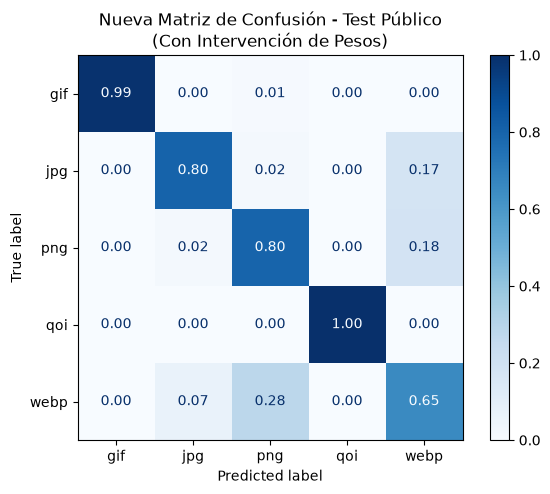

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Asumiendo que tu ensamble te devolvió las probabilidades del test público en una variable, 
# por ejemplo 'probas_promedio_publico', y que tenés las 'etiquetas_test' reales.

# 1. Si tu ensamble devolvió probabilidades, extraemos el índice de la clase ganadora:
y_pred_indices = np.argmax(probas_ensamble_publico, axis=1) 
# (Si tu ensamble ya devolvió texto ['png', 'webp', ...], avisame y cambiamos un par de líneas)

# 2. Pasamos las etiquetas reales del test público de one-hot a índices numéricos:
y_real_indices = np.argmax(etiquetas_test, axis=1)

# 3. Las clases en orden alfabético (como las armó pd.get_dummies)
clases = ['gif', 'jpg', 'png', 'qoi', 'webp']

# 4. Calculamos la matriz normalizada (para que de porcentajes por fila, como en tu captura)
cm = confusion_matrix(y_real_indices, y_pred_indices, normalize='true')

# 5. Dibujamos el gráfico
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')

plt.title('Nueva Matriz de Confusión - Test Público\n(Con Intervención de Pesos)')
plt.show()

Implementacion de Stacking y 6ta entrega

1. Cargando datos...
2. Extrayendo features y aplicando poda...
3. Entrenando Ensamble K-Fold para generar meta-features (OOF)...
   --- Fold base 1/10 ---
   --- Fold base 2/10 ---
   --- Fold base 3/10 ---
   --- Fold base 4/10 ---
   --- Fold base 5/10 ---
   --- Fold base 6/10 ---
   --- Fold base 7/10 ---
   --- Fold base 8/10 ---
   --- Fold base 9/10 ---
   --- Fold base 10/10 ---

4. Entrenando el Meta-Modelo (Regresión Logística)...
5. Evaluando en Test Público...

---> ACCURACY FINAL STACKING EN TEST PÚBLICO: 90.00% <---


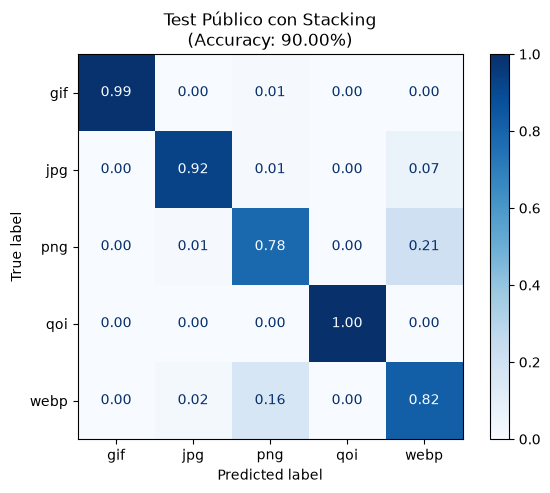

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from keras.utils import to_categorical

# 1. Cargar train completo y test público
print("1. Cargando datos...")
dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
datos_train = dataset[:, :512].astype('float32') / 255.0
etiq_train_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e.strip()] for e in dataset[:, 512]])
trainY_onehot = to_categorical(etiq_train_num, num_classes=5)

publico = np.loadtxt('../dataset/test_publico.csv', delimiter=',', dtype=str)
publico_crudo = publico[:, :512].astype('float32') / 255.0
publicoY_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e.strip()] for e in publico[:, 512]])

# 2. Features, Poda y Scaler
print("2. Extrayendo features y aplicando poda...")
train_feat = enriquecer_features(datos_train)
publico_feat = enriquecer_features(publico_crudo)

bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque.fit(train_feat, etiq_train_num)
indices_top = np.argsort(bosque.feature_importances_)[::-1][:800]

scaler = StandardScaler()
trainX_final = scaler.fit_transform(train_feat[:, indices_top])
publicoX_final = scaler.transform(publico_feat[:, indices_top])

# 3. Arquitectura Campeona (Fase 6)
def definir_modelo_campeon():
    modelo = Sequential([
        keras.Input(shape=(800,)),
        Dense(448, activation='swish'), BatchNormalization(), Dropout(0.3),
        Dense(64, activation='swish'), BatchNormalization(), Dropout(0.4),
        Dense(5, activation='softmax')
    ])
    modelo.compile(
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        optimizer=keras.optimizers.AdamW(learning_rate=0.0001, weight_decay=0.004),
        metrics=['accuracy']
    )
    return modelo

# 4. K-Fold OOF y predicciones base del público
print("3. Entrenando Ensamble K-Fold para generar meta-features (OOF)...")
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

oof_probas = np.zeros((len(trainX_final), 5))
probas_totales_publico = np.zeros((len(publicoX_final), 5))

# Pesos manuales
pesos_clases = {0: 1.0, 1: 1.5, 2: 3.0, 3: 1.0, 4: 3.0} 

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

fold_actual = 1
for train_ix, val_ix in kfold.split(trainX_final):
    print(f"   --- Fold base {fold_actual}/10 ---")
    tX, vX = trainX_final[train_ix], trainX_final[val_ix]
    tY, vY = trainY_onehot[train_ix], trainY_onehot[val_ix]
    
    modelo = definir_modelo_campeon()
    modelo.fit(tX, tY, epochs=150, batch_size=32, validation_data=(vX, vY),
               callbacks=[early_stop, reduce_lr], class_weight=pesos_clases, verbose=0)
    
    oof_probas[val_ix] = modelo.predict(vX, verbose=0)
    probas_totales_publico += modelo.predict(publicoX_final, verbose=0)
    fold_actual += 1

probas_publico_base = probas_totales_publico / 10.0

# 5. Entrenando el Meta-Modelo
print("\n4. Entrenando el Meta-Modelo (Regresión Logística)...")
meta_modelo = LogisticRegression(max_iter=1000, random_state=42)
meta_modelo.fit(oof_probas, etiq_train_num)

# 6. Evaluación Final
print("5. Evaluando en Test Público...")
predicciones_stacking = meta_modelo.predict(probas_publico_base)

acc_stacking = accuracy_score(publicoY_num, predicciones_stacking)
print(f"\n---> ACCURACY FINAL STACKING EN TEST PÚBLICO: {acc_stacking * 100:.2f}% <---")

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
cm = confusion_matrix(publicoY_num, predicciones_stacking, normalize='true')
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title(f'Test Público con Stacking\n(Accuracy: {acc_stacking * 100:.2f}%)')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from keras.utils import to_categorical

# 1. Cargar el 100% de los datos
dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
datos_completos = dataset[:, :512].astype('float32') / 255.0
etiq_txt = np.array([e.strip() for e in dataset[:, 512]])
etiq_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e] for e in etiq_txt])
etiq_onehot = to_categorical(etiq_num, num_classes=5)

ciego = np.loadtxt('../dataset/clasificacion_test_features.csv', delimiter=',', dtype='float32') / 255.0

# 2. Features originales, Poda y Scaler
print("1. Procesando features y aplicando poda...")
features_completos = enriquecer_features(datos_completos)
ciego_feat_comp = enriquecer_features(ciego)

bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque.fit(features_completos, etiq_num)
indices_top = np.argsort(bosque.feature_importances_)[::-1][:800]

scaler = StandardScaler()
dataX_final = scaler.fit_transform(features_completos[:, indices_top])
ciegoX = scaler.transform(ciego_feat_comp[:, indices_top])

# 3. Arquitectura Campeona
def definir_modelo_campeon():
    modelo = Sequential([
        keras.Input(shape=(800,)),
        Dense(448, activation='swish'), BatchNormalization(), Dropout(0.3),
        Dense(64, activation='swish'), BatchNormalization(), Dropout(0.4),
        Dense(5, activation='softmax')
    ])
    modelo.compile(
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        optimizer=keras.optimizers.AdamW(learning_rate=0.0001, weight_decay=0.004),
        metrics=['accuracy']
    )
    return modelo

# 4. Generación OOF y predicciones base del Ciego
print("2. Generando meta-features OOF (10 Folds)...")
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

oof_probas = np.zeros((len(dataX_final), 5))      
probas_totales_ciego = np.zeros((len(ciegoX), 5)) 
pesos_clases = {0: 1.0, 1: 1.5, 2: 3.0, 3: 1.0, 4: 3.0} 

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

fold_actual = 1
for train_ix, val_ix in kfold.split(dataX_final):
    print(f"   --- Fold {fold_actual}/10 ---")
    tX, vX = dataX_final[train_ix], dataX_final[val_ix]
    tY, vY = etiq_onehot[train_ix], etiq_onehot[val_ix]
    
    modelo = definir_modelo_campeon()
    modelo.fit(tX, tY, epochs=150, batch_size=32, validation_data=(vX, vY),
               callbacks=[early_stop, reduce_lr], class_weight=pesos_clases, verbose=0)
    
    oof_probas[val_ix] = modelo.predict(vX, verbose=0)
    probas_totales_ciego += modelo.predict(ciegoX, verbose=0)
    fold_actual += 1

probas_ciego_base = probas_totales_ciego / 10.0

# 5. EL META-MODELO (Regresión Logística)
print("3. Entrenando el Meta-Modelo para corregir sesgos...")
meta_modelo = LogisticRegression(max_iter=1000, random_state=42)
meta_modelo.fit(oof_probas, etiq_num)

# 6. Predicción Final Ciega y CSV
print("4. Generando CSV final...")
predicciones_indices = meta_modelo.predict(probas_ciego_base)

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
predicciones_texto = [clases[i] for i in predicciones_indices]

pd.DataFrame({'y_pred': predicciones_texto}).to_csv('entrega_stacking_definitiva.csv', index=False)
print("¡Archivo entrega_6.csv generado con éxito!")

1. Procesando features y aplicando poda...
2. Generando meta-features OOF (10 Folds)...
   --- Fold 1/10 ---
   --- Fold 2/10 ---
   --- Fold 3/10 ---
   --- Fold 4/10 ---
   --- Fold 5/10 ---
   --- Fold 6/10 ---
   --- Fold 7/10 ---
   --- Fold 8/10 ---
   --- Fold 9/10 ---
   --- Fold 10/10 ---
3. Entrenando el Meta-Modelo para corregir sesgos...
4. Generando CSV final...
¡Archivo entrega_6.csv generado con éxito!


Aplicando Cosine Annealing

1. Cargando datos...
2. Extrayendo features y aplicando poda...
3. Entrenando Ensamble K-Fold con Cosine Annealing (OOF)...
   --- Fold base 1/10 ---
   --- Fold base 2/10 ---
   --- Fold base 3/10 ---
   --- Fold base 4/10 ---
   --- Fold base 5/10 ---
   --- Fold base 6/10 ---
   --- Fold base 7/10 ---
   --- Fold base 8/10 ---
   --- Fold base 9/10 ---
   --- Fold base 10/10 ---

4. Entrenando el Meta-Modelo (Regresión Logística)...
5. Evaluando en Test Público...

---> ACCURACY FINAL (STACKING + COSINE ANNEALING): 89.20% <---


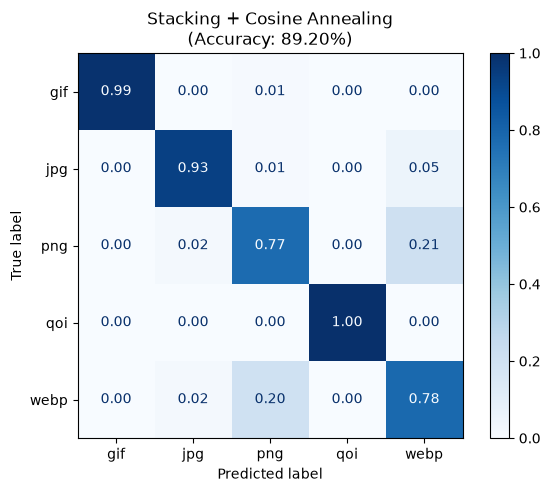

In [ ]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from keras.utils import to_categorical
from keras.callbacks import LearningRateScheduler, EarlyStopping

# 1. Cargar train completo y test público
print("1. Cargando datos...")
dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
datos_train = dataset[:, :512].astype('float32') / 255.0
etiq_train_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e.strip()] for e in dataset[:, 512]])
trainY_onehot = to_categorical(etiq_train_num, num_classes=5)

publico = np.loadtxt('../dataset/test_publico.csv', delimiter=',', dtype=str)
publico_crudo = publico[:, :512].astype('float32') / 255.0
publicoY_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e.strip()] for e in publico[:, 512]])

# 2. Features, Poda y Scaler
print("2. Extrayendo features y aplicando poda...")
train_feat = enriquecer_features(datos_train)
publico_feat = enriquecer_features(publico_crudo)

bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque.fit(train_feat, etiq_train_num)
indices_top = np.argsort(bosque.feature_importances_)[::-1][:800]

scaler = StandardScaler()
trainX_final = scaler.fit_transform(train_feat[:, indices_top])
publicoX_final = scaler.transform(publico_feat[:, indices_top])

# 3. EL SECRETO: Cosine Annealing con Warm Restarts
def programador_coseno(epoch):
    lr_min = 1e-5
    lr_max = 0.00025  # Arranca un poco más alto para aprovechar los saltos
    ciclo_epochs = 20 # Cada 20 épocas, patea el LR de vuelta al máximo
    
    fraccion = (epoch % ciclo_epochs) / ciclo_epochs
    lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * fraccion))
    return lr

lr_scheduler = LearningRateScheduler(programador_coseno)
early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

# 4. Arquitectura Campeona (Fase 6)
def definir_modelo_campeon():
    modelo = Sequential([
        keras.Input(shape=(800,)),
        Dense(448, activation='swish'), BatchNormalization(), Dropout(0.3),
        Dense(64, activation='swish'), BatchNormalization(), Dropout(0.4),
        Dense(5, activation='softmax')
    ])
    # El LR inicial acá no importa porque lo sobreescribe el scheduler
    modelo.compile(
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        optimizer=keras.optimizers.AdamW(weight_decay=0.004),
        metrics=['accuracy']
    )
    return modelo

# 5. K-Fold OOF para meta-features
print("3. Entrenando Ensamble K-Fold con Cosine Annealing (OOF)...")
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

oof_probas = np.zeros((len(trainX_final), 5))
probas_totales_publico = np.zeros((len(publicoX_final), 5))
pesos_clases = {0: 1.0, 1: 1.5, 2: 3.0, 3: 1.0, 4: 3.0} 

fold_actual = 1
for train_ix, val_ix in kfold.split(trainX_final):
    print(f"   --- Fold base {fold_actual}/10 ---")
    tX, vX = trainX_final[train_ix], trainX_final[val_ix]
    tY, vY = trainY_onehot[train_ix], trainY_onehot[val_ix]
    
    modelo = definir_modelo_campeon()
    modelo.fit(tX, tY, epochs=150, batch_size=32, validation_data=(vX, vY),
               callbacks=[early_stop, lr_scheduler], class_weight=pesos_clases, verbose=0)
    
    oof_probas[val_ix] = modelo.predict(vX, verbose=0)
    probas_totales_publico += modelo.predict(publicoX_final, verbose=0)
    fold_actual += 1

probas_publico_base = probas_totales_publico / 10.0

# 6. Entrenando el Meta-Modelo
print("\n4. Entrenando el Meta-Modelo (Regresión Logística)...")
meta_modelo = LogisticRegression(max_iter=1000, random_state=42)
meta_modelo.fit(oof_probas, etiq_train_num)

# 7. Evaluación Final
print("5. Evaluando en Test Público...")
predicciones_stacking = meta_modelo.predict(probas_publico_base)

acc_stacking = accuracy_score(publicoY_num, predicciones_stacking)
print(f"\n---> ACCURACY FINAL (STACKING + COSINE ANNEALING): {acc_stacking * 100:.2f}% <---")

import matplotlib.pyplot as plt
clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
cm = confusion_matrix(publicoY_num, predicciones_stacking, normalize='true')
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title(f'Stacking + Cosine Annealing\n(Accuracy: {acc_stacking * 100:.2f}%)')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from keras.utils import to_categorical

# 1. Cargar el 100% de los datos de entrenamiento y el test ciego
print("1. Cargando datos...")
dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
datos_completos = dataset[:, :512].astype('float32') / 255.0
etiq_txt = np.array([e.strip() for e in dataset[:, 512]])
etiq_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e] for e in etiq_txt])
etiq_onehot = to_categorical(etiq_num, num_classes=5)

ciego = np.loadtxt('../dataset/clasificacion_test_features.csv', delimiter=',', dtype='float32') / 255.0

# 2. Features originales, Poda y Scaler
print("2. Extrayendo features y aplicando poda...")
features_completos = enriquecer_features(datos_completos)
ciego_feat_comp = enriquecer_features(ciego)

bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque.fit(features_completos, etiq_num)
indices_top = np.argsort(bosque.feature_importances_)[::-1][:800]

scaler = StandardScaler()
dataX_final = scaler.fit_transform(features_completos[:, indices_top])
ciegoX = scaler.transform(ciego_feat_comp[:, indices_top])

# 3. Arquitectura Campeona (Fase 6)
def definir_modelo_campeon():
    modelo = Sequential([
        keras.Input(shape=(800,)),
        Dense(448, activation='swish'), BatchNormalization(), Dropout(0.3),
        Dense(64, activation='swish'), BatchNormalization(), Dropout(0.4),
        Dense(5, activation='softmax')
    ])
    modelo.compile(
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        optimizer=keras.optimizers.AdamW(learning_rate=0.0001, weight_decay=0.004),
        metrics=['accuracy']
    )
    return modelo

# 4. Generación de predicciones Out-Of-Fold (OOF) para el Stacking
print("3. Entrenando Ensamble K-Fold para generar meta-features (OOF)...")
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

# Matrices para guardar los resultados
oof_probas = np.zeros((len(dataX_final), 5))      # Probabilidades para el meta-modelo
probas_totales_ciego = np.zeros((len(ciegoX), 5)) # Promedio del test ciego

# Pesos normales para que el meta-modelo aprenda el sesgo real
pesos_clases = {0: 1.0, 1: 1.5, 2: 3.0, 3: 1.0, 4: 3.0} 

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

fold_actual = 1
for train_ix, val_ix in kfold.split(dataX_final):
    print(f"   --- Fold base {fold_actual}/10 ---")
    tX, vX = dataX_final[train_ix], dataX_final[val_ix]
    tY, vY = etiq_onehot[train_ix], etiq_onehot[val_ix]
    
    modelo = definir_modelo_campeon()
    modelo.fit(tX, tY, epochs=150, batch_size=32, validation_data=(vX, vY),
               callbacks=[early_stop, reduce_lr], class_weight=pesos_clases, verbose=0)
    
    # Guardamos las probabilidades puras (no memorizadas)
    oof_probas[val_ix] = modelo.predict(vX, verbose=0)
    
    # Sumamos las predicciones del ciego
    probas_totales_ciego += modelo.predict(ciegoX, verbose=0)
    fold_actual += 1

# Promediamos las predicciones del ciego de los 10 modelos
probas_ciego_base = probas_totales_ciego / 10.0

# 5. EL META-MODELO (Stacking)
print("\n4. Entrenando el Meta-Modelo (Regresión Logística) para corregir sesgos...")
# Entrenamos la regresión logística usando las probabilidades puras del OOF contra las etiquetas reales
meta_modelo = LogisticRegression(max_iter=1000, random_state=42)
meta_modelo.fit(oof_probas, etiq_num)

# 6. Predicción Final y CSV
print("5. Prediciendo el Test Ciego con el Meta-Modelo...")
predicciones_indices = meta_modelo.predict(probas_ciego_base)

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
predicciones_texto = [clases[i] for i in predicciones_indices]

pd.DataFrame({'y_pred': predicciones_texto}).to_csv('entrega_stacking.csv', index=False)
print("¡Archivo entrega_stacking.csv generado con éxito!")

1. Cargando datos...
2. Extrayendo features y aplicando poda...
3. Entrenando Ensamble K-Fold para generar meta-features (OOF)...
   --- Fold base 1/10 ---
   --- Fold base 2/10 ---
   --- Fold base 3/10 ---
   --- Fold base 4/10 ---
   --- Fold base 5/10 ---
   --- Fold base 6/10 ---
   --- Fold base 7/10 ---
   --- Fold base 8/10 ---
   --- Fold base 9/10 ---
   --- Fold base 10/10 ---

4. Entrenando el Meta-Modelo (Regresión Logística) para corregir sesgos...
5. Prediciendo el Test Ciego con el Meta-Modelo...
¡Archivo entrega_stacking.csv generado con éxito!


Pueba con seed blending

1. Cargando datos...
2. Extrayendo features y aplicando poda...
3. Pesos aplicados: {0: np.float64(1.0), 1: np.float64(1.5), 2: np.float64(2.5), 3: np.float64(1.0), 4: np.float64(0.5)}
4. Iniciando Seed Blending (5 semillas x 10 Folds)...

---> Semilla de Aleatoriedad (RNG): 42 <---
  Fold 1/10 listo
  Fold 2/10 listo
  Fold 3/10 listo
  Fold 4/10 listo
  Fold 5/10 listo
  Fold 6/10 listo
  Fold 7/10 listo
  Fold 8/10 listo
  Fold 9/10 listo
  Fold 10/10 listo

---> Semilla de Aleatoriedad (RNG): 1 <---
  Fold 1/10 listo
  Fold 2/10 listo
  Fold 3/10 listo
  Fold 4/10 listo
  Fold 5/10 listo
  Fold 6/10 listo
  Fold 7/10 listo
  Fold 8/10 listo
  Fold 9/10 listo
  Fold 10/10 listo

---> Semilla de Aleatoriedad (RNG): 123 <---
  Fold 1/10 listo
  Fold 2/10 listo
  Fold 3/10 listo
  Fold 4/10 listo
  Fold 5/10 listo
  Fold 6/10 listo
  Fold 7/10 listo
  Fold 8/10 listo
  Fold 9/10 listo
  Fold 10/10 listo

---> Semilla de Aleatoriedad (RNG): 777 <---
  Fold 1/10 listo
  Fold 2/10 listo
 

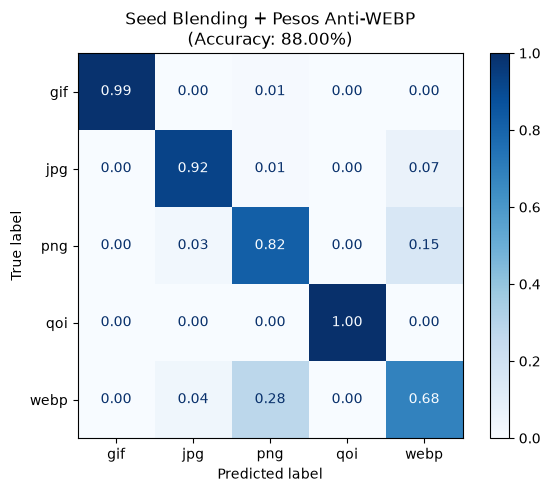

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from keras.utils import to_categorical

# 1. Cargar train completo y test público
print("1. Cargando datos...")
dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
datos_train = dataset[:, :512].astype('float32') / 255.0
etiq_train_txt = np.array([e.strip() for e in dataset[:, 512]])
etiq_train_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e] for e in etiq_train_txt])
trainY_onehot = to_categorical(etiq_train_num, num_classes=5)

publico = np.loadtxt('../dataset/test_publico.csv', delimiter=',', dtype=str)
publico_crudo = publico[:, :512].astype('float32') / 255.0
publicoY_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e.strip()] for e in publico[:, 512]])

# 2. Features y Poda Random Forest
print("2. Extrayendo features y aplicando poda...")
train_feat = enriquecer_features(datos_train)
publico_feat = enriquecer_features(publico_crudo)

bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque.fit(train_feat, etiq_train_num)
indices_top = np.argsort(bosque.feature_importances_)[::-1][:800]

scaler = StandardScaler()
trainX_final = scaler.fit_transform(train_feat[:, indices_top])
publicoX_final = scaler.transform(publico_feat[:, indices_top])

# 3. Pesos Tácticos Anti-WEBP
pesos_array = compute_class_weight('balanced', classes=np.unique(etiq_train_num), y=etiq_train_num)
pesos_mod = dict(enumerate(pesos_array))
pesos_mod[2] = pesos_mod[2] * 2.5  # Boost al PNG
pesos_mod[1] = pesos_mod[1] * 1.5  # Boost al JPG
pesos_mod[4] = pesos_mod[4] * 0.5  # Castigo al WEBP

print(f"3. Pesos aplicados: {pesos_mod}")

# 4. Arquitectura Campeona
def definir_modelo_campeon():
    modelo = Sequential([
        keras.Input(shape=(800,)),
        Dense(448, activation='swish'), BatchNormalization(), Dropout(0.3),
        Dense(64, activation='swish'), BatchNormalization(), Dropout(0.4),
        Dense(5, activation='softmax')
    ])
    modelo.compile(
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        optimizer=keras.optimizers.AdamW(learning_rate=0.0001, weight_decay=0.004),
        metrics=['accuracy']
    )
    return modelo

# 5. SEED BLENDING (5 Semillas) Evaluando en Test Público
semillas = [42, 1, 123, 777, 2026]
probas_totales_publico = np.zeros((len(publicoX_final), 5))

print("4. Iniciando Seed Blending (5 semillas x 10 Folds)...")

for seed in semillas:
    print(f"\n---> Semilla de Aleatoriedad (RNG): {seed} <---")
    keras.utils.set_random_seed(seed)
    
    kfold = KFold(n_splits=10, shuffle=True, random_state=seed)
    
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
    
    fold_actual = 1
    for train_ix, val_ix in kfold.split(trainX_final):
        tX, vX = trainX_final[train_ix], trainX_final[val_ix]
        tY, vY = trainY_onehot[train_ix], trainY_onehot[val_ix]
        
        modelo = definir_modelo_campeon()
        modelo.fit(tX, tY, epochs=150, batch_size=32, validation_data=(vX, vY),
                   callbacks=[early_stop, reduce_lr], class_weight=pesos_mod, verbose=0)
        
        probas_totales_publico += modelo.predict(publicoX_final, verbose=0)
        print(f"  Fold {fold_actual}/10 listo")
        fold_actual += 1

# 6. Evaluación Final
print("\n5. Calculando métricas en Test Público...")
probas_promedio = probas_totales_publico / 50.0 
predicciones = np.argmax(probas_promedio, axis=1)

acc = accuracy_score(publicoY_num, predicciones)
print(f"\n---> ACCURACY FINAL SEED BLENDING: {acc * 100:.2f}% <---")

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
cm = confusion_matrix(publicoY_num, predicciones, normalize='true')
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title(f'Seed Blending + Pesos Anti-WEBP\n(Accuracy: {acc * 100:.2f}%)')
plt.show()

Aumentando datos

In [ ]:
%pip install qoi

  Using cached qoi-0.8.0-cp311-abi3-win_amd64.whl.metadata (11 kB)
Using cached qoi-0.8.0-cp311-abi3-win_amd64.whl (3.2 MB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import qoi  # Requiere: pip install qoi
import random

# 1. Crear carpeta temporal para fabricar los archivos
os.makedirs('dataset_sintetico', exist_ok=True)

formatos = ['gif', 'jpg', 'png', 'qoi', 'webp']
nuevos_datos = []
etiquetas = []

CANTIDAD_A_GENERAR = 10000  # Podés subirlo a 20000 o 50000 si querés

print(f"Fabricando {CANTIDAD_A_GENERAR} archivos nuevos...")

for i in range(CANTIDAD_A_GENERAR):
    # Generar una imagen RGB aleatoria de tamaño variable para cambiar los encabezados
    w, h = random.randint(50, 300), random.randint(50, 300)
    matriz_pixeles = np.random.randint(0, 256, (h, w, 3), dtype=np.uint8)
    img = Image.fromarray(matriz_pixeles)
    
    # Elegir un formato al azar
    fmt = random.choice(formatos)
    ruta = f"dataset_sintetico/img_{i}.{fmt}"
    
    # Guardar el archivo físicamente para que el motor de compresión arme el header real
    if fmt == 'qoi':
        qoi.write(ruta, matriz_pixeles)
    elif fmt == 'jpg':
        # Pillow usa 'jpeg' como nombre de formato interno
        img.save(ruta, format='jpeg', quality=random.randint(50, 100))
    else:
        img.save(ruta, format=fmt)
        
    # Leer los primeros 512 bytes del archivo recién creado
    with open(ruta, 'rb') as f:
        bytes_leidos = list(f.read(512))
        
    # Si por alguna razón el archivo pesa menos de 512 bytes, rellenamos con ceros
    if len(bytes_leidos) < 512:
        bytes_leidos.extend([0] * (512 - len(bytes_leidos)))
    else:
        bytes_leidos = bytes_leidos[:512]
        
    nuevos_datos.append(bytes_leidos)
    etiquetas.append(fmt)

    if (i + 1) % 2000 == 0:
        print(f"Generados {i + 1} archivos...")

# 2. Convertir todo a un DataFrame y guardarlo como CSV
print("Armando el CSV ampliado...")
df_nuevo = pd.DataFrame(nuevos_datos)
df_nuevo['label'] = etiquetas

# Guardar el dataset extra
df_nuevo.to_csv('dataset_ampliado.csv', index=False, header=False)
print("¡Listo! Archivo 'dataset_ampliado.csv' generado con éxito.")

Fabricando 10000 archivos nuevos...
Generados 2000 archivos...
Generados 4000 archivos...
Generados 6000 archivos...
Generados 8000 archivos...
Generados 10000 archivos...
Armando el CSV ampliado...
¡Listo! Archivo 'dataset_ampliado.csv' generado con éxito.


Implementacion de ensamble multiarquitectura

In [ ]:
#Tuner
import keras_tuner as kt
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Separamos un 20% del entrenamiento usando TUS variables cargadas en memoria
X_train_t, X_val_t, y_train_t, y_val_t = train_test_split(
    trainX_final, trainY_onehot, test_size=0.2, random_state=42, stratify=trainY_num
)

# 2. Definimos el espacio de búsqueda dinámico
def construir_modelo_dinamico(hp):
    modelo = Sequential()
    modelo.add(keras.Input(shape=(800,)))
    
    # El tuner decide si usa 1, 2 o 3 capas ocultas
    for i in range(hp.Int('num_capas', 1, 3)):
        modelo.add(Dense(
            units=hp.Int(f'neuronas_{i}', min_value=64, max_value=1024, step=64),
            activation='swish'
        ))
        modelo.add(BatchNormalization())
        modelo.add(Dropout(hp.Float(f'dropout_{i}', min_value=0.1, max_value=0.5, step=0.1)))
        
    modelo.add(Dense(5, activation='softmax'))
    
    modelo.compile(
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        optimizer=keras.optimizers.AdamW(
            learning_rate=hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4]),
            weight_decay=0.004
        ),
        metrics=['accuracy']
    )
    return modelo

# 3. Configuramos la búsqueda Bayesiana
tuner = kt.BayesianOptimization(
    construir_modelo_dinamico,
    objective='val_accuracy',
    max_trials=15, 
    directory='tuner_multiarquitectura',
    project_name='top_3_ensamble',
    overwrite=True
)

# 4. A buscar
print("Iniciando búsqueda de las mejores 3 arquitecturas...")
tuner.search(
    X_train_t, y_train_t, 
    epochs=40, 
    batch_size=32, 
    validation_data=(X_val_t, y_val_t), 
    verbose=1
)

# 5. Extraer e imprimir las 3 ganadoras
mejores_hps = tuner.get_best_hyperparameters(num_trials=3)

print("\n--- TOP 3 ARQUITECTURAS ENCONTRADAS PARA LLEVAR A TU ENSAMBLE ---")
for i, hp in enumerate(mejores_hps):
    print(f"\nModelo {i+1}:")
    capas = hp.get('num_capas')
    for j in range(capas):
        print(f"  - Capa oculta {j+1}: {hp.get(f'neuronas_{j}')} neuronas, Dropout: {hp.get(f'dropout_{j}')}")
    print(f"  - Learning Rate: {hp.get('learning_rate')}")

Trial 15 Complete [00h 00m 08s]
val_accuracy: 0.918749988079071

Best val_accuracy So Far: 0.9300000071525574
Total elapsed time: 00h 02m 20s

--- TOP 3 ARQUITECTURAS ENCONTRADAS PARA LLEVAR A TU ENSAMBLE ---

Modelo 1:
  - Capa oculta 1: 256 neuronas, Dropout: 0.2
  - Capa oculta 2: 320 neuronas, Dropout: 0.30000000000000004
  - Learning Rate: 0.001

Modelo 2:
  - Capa oculta 1: 576 neuronas, Dropout: 0.30000000000000004
  - Capa oculta 2: 512 neuronas, Dropout: 0.2
  - Capa oculta 3: 64 neuronas, Dropout: 0.1
  - Learning Rate: 0.001

Modelo 3:
  - Capa oculta 1: 640 neuronas, Dropout: 0.1
  - Capa oculta 2: 576 neuronas, Dropout: 0.5
  - Capa oculta 3: 768 neuronas, Dropout: 0.2
  - Learning Rate: 0.0005


1. Cargando y fusionando datasets...
2. Extrayendo features de las 14000 muestras...
3. Podando con Random Forest sobre datos masivos...
4. Entrenando el Mega-Ensamble...
   --- Fold 1/5 ---


c:\facu\ia\red-neuronal-regresion-IA-2026\.venv\Lib\site-packages\keras\src\layers\regularization\gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   --- Fold 2/5 ---
   --- Fold 3/5 ---
   --- Fold 4/5 ---
   --- Fold 5/5 ---

---> ACCURACY FINAL EN TEST PÚBLICO (DATASET EXPANDIDO): 88.40% <---


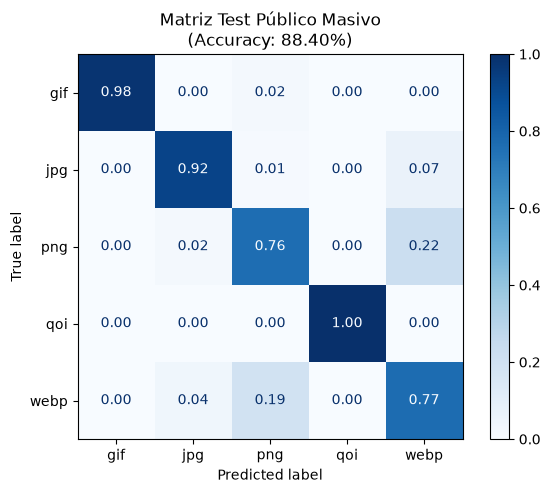

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout, GaussianNoise
from keras.utils import to_categorical

# 1. Cargar y fusionar la data original con la ampliada
print("1. Cargando y fusionando datasets...")
dataset_orig = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
datos_orig = dataset_orig[:, :512].astype('float32') / 255.0
etiq_orig_txt = np.array([e.strip() for e in dataset_orig[:, 512]])

dataset_amp = np.loadtxt('dataset_ampliado.csv', delimiter=',', dtype=str)
datos_amp = dataset_amp[:, :512].astype('float32') / 255.0
etiq_amp_txt = np.array([e.strip() for e in dataset_amp[:, 512]])

# Concatenación masiva
datos_masivos = np.vstack((datos_orig, datos_amp))
etiq_masivas_txt = np.concatenate((etiq_orig_txt, etiq_amp_txt))

etiq_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e] for e in etiq_masivas_txt])
trainY = to_categorical(etiq_num, num_classes=5)

publico = np.loadtxt('../dataset/test_publico.csv', delimiter=',', dtype=str)
publico_crudo = publico[:, :512].astype('float32') / 255.0
publicoY_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e.strip()] for e in publico[:, 512]])

# 2. Features, Poda y Escalado sobre el mega-dataset
print(f"2. Extrayendo features de las {len(datos_masivos)} muestras...")
train_feat = enriquecer_features(datos_masivos)
publico_feat = enriquecer_features(publico_crudo)

print("3. Podando con Random Forest sobre datos masivos...")
bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque.fit(train_feat, etiq_num)
indices_top = np.argsort(bosque.feature_importances_)[::-1][:800]

scaler = StandardScaler()
trainX_final = scaler.fit_transform(train_feat[:, indices_top])
publicoX_final = scaler.transform(publico_feat[:, indices_top])

# 3. Modelos Top 3 Tuner + GaussianNoise
def modelo_tuner_1_reg():
    m = Sequential([
        GaussianNoise(0.05, input_shape=(800,)),
        Dense(256, activation='swish'), BatchNormalization(), Dropout(0.2),
        Dense(320, activation='swish'), BatchNormalization(), Dropout(0.3),
        Dense(5, activation='softmax')
    ])
    m.compile(loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              optimizer=keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.004), metrics=['accuracy'])
    return m

def modelo_tuner_2_reg():
    m = Sequential([
        GaussianNoise(0.05, input_shape=(800,)),
        Dense(576, activation='swish'), BatchNormalization(), Dropout(0.3),
        Dense(512, activation='swish'), BatchNormalization(), Dropout(0.2),
        Dense(64, activation='swish'), BatchNormalization(), Dropout(0.1),
        Dense(5, activation='softmax')
    ])
    m.compile(loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              optimizer=keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.004), metrics=['accuracy'])
    return m

def modelo_tuner_3_reg():
    m = Sequential([
        GaussianNoise(0.05, input_shape=(800,)),
        Dense(640, activation='swish'), BatchNormalization(), Dropout(0.1),
        Dense(576, activation='swish'), BatchNormalization(), Dropout(0.5),
        Dense(768, activation='swish'), BatchNormalization(), Dropout(0.2),
        Dense(5, activation='softmax')
    ])
    m.compile(loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              optimizer=keras.optimizers.AdamW(learning_rate=0.0005, weight_decay=0.004), metrics=['accuracy'])
    return m

arquitecturas = [modelo_tuner_1_reg, modelo_tuner_2_reg, modelo_tuner_3_reg]

# 4. Entrenamiento del Mega-Ensamble
print("4. Entrenando el Mega-Ensamble...")
kfold = KFold(n_splits=5, shuffle=True, random_state=1)
probas_totales = np.zeros((len(publicoX_final), 5))
pesos_clases = {0: 1.0, 1: 1.5, 2: 3.0, 3: 1.0, 4: 3.0}

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

fold_actual = 1
for train_ix, val_ix in kfold.split(trainX_final):
    print(f"   --- Fold {fold_actual}/5 ---")
    tX, vX = trainX_final[train_ix], trainX_final[val_ix]
    tY, vY = trainY[train_ix], trainY[val_ix]
    
    for fn in arquitecturas:
        m = fn()
        m.fit(tX, tY, epochs=100, batch_size=64, validation_data=(vX, vY),
              callbacks=[early_stop, reduce_lr], class_weight=pesos_clases, verbose=0)
        probas_totales += m.predict(publicoX_final, verbose=0)
        
    fold_actual += 1

# 5. Evaluación Test Público
probas_promedio = probas_totales / 15.0  # 5 Folds x 3 arquitecturas = 15 modelos totales
predicciones = np.argmax(probas_promedio, axis=1)

acc = accuracy_score(publicoY_num, predicciones)
print(f"\n---> ACCURACY FINAL EN TEST PÚBLICO (DATASET EXPANDIDO): {acc * 100:.2f}% <---")

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
cm = confusion_matrix(publicoY_num, predicciones, normalize='true')
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title(f'Matriz Test Público Masivo\n(Accuracy: {acc * 100:.2f}%)')
plt.show()

1. Enriqueciendo características de dataset.csv (3078)...
2. Aplicando poda (Random Forest Top 800) y escalado...
3. Entrenando validación cruzada OOF (10 folds x 3 arquitecturas)...
   --- Fold 1/10 ---
   --- Fold 2/10 ---
   --- Fold 3/10 ---
   --- Fold 4/10 ---
   --- Fold 5/10 ---
   --- Fold 6/10 ---
   --- Fold 7/10 ---
   --- Fold 8/10 ---
   --- Fold 9/10 ---
   --- Fold 10/10 ---

---> ACCURACY GLOBAL OOF EN DATASET.CSV: 91.65% <---


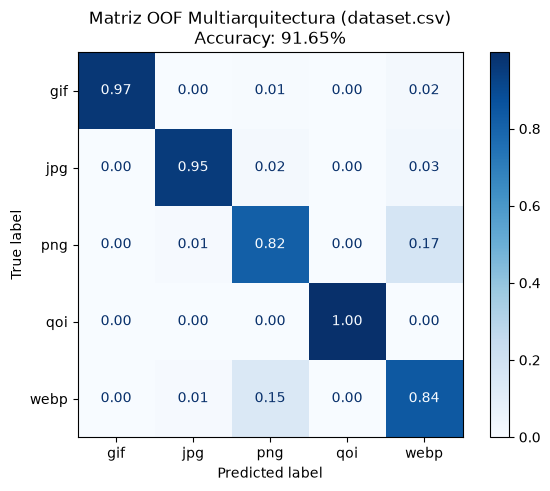

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout, GaussianNoise
from keras.utils import to_categorical


# 1. Cargar las 4000 muestras completas de dataset.csv
dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
datos_crudos = dataset[:, :512].astype('float32') / 255.0
etiq_txt = np.array([e.strip() for e in dataset[:, 512]])
etiq_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e] for e in etiq_txt])
etiq_onehot = to_categorical(etiq_num, num_classes=5)

# 2. Enriquecimiento completo
print("1. Enriqueciendo características de dataset.csv (3078)...")
features_comp = enriquecer_features(datos_crudos)

# 3. Poda Top 800 y escalado
print("2. Aplicando poda (Random Forest Top 800) y escalado...")
bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque.fit(features_comp, etiq_num)
indices_top = np.argsort(bosque.feature_importances_)[::-1][:800]

scaler = StandardScaler()
X_final = scaler.fit_transform(features_comp[:, indices_top])
y_final = etiq_onehot

# 4. Definición de las 3 arquitecturas densas
def modelo_tuner_1():
    m = Sequential([
        keras.Input(shape=(800,)),
        GaussianNoise(0.05),
        Dense(256, activation='swish'), BatchNormalization(), Dropout(0.2),
        Dense(320, activation='swish'), BatchNormalization(), Dropout(0.3),
        Dense(5, activation='softmax')
    ])
    m.compile(loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              optimizer=keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.004), 
              metrics=['accuracy'])
    return m

def modelo_tuner_2():
    m = Sequential([
        keras.Input(shape=(800,)),
        Dense(576, activation='swish'), BatchNormalization(), Dropout(0.3),
        Dense(512, activation='swish'), BatchNormalization(), Dropout(0.2),
        Dense(64, activation='swish'), BatchNormalization(), Dropout(0.1),
        Dense(5, activation='softmax')
    ])
    m.compile(loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              optimizer=keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.004), 
              metrics=['accuracy'])
    return m

def modelo_tuner_3():
    m = Sequential([
        keras.Input(shape=(800,)),
        Dense(640, activation='swish'), BatchNormalization(), Dropout(0.1),
        Dense(576, activation='swish'), BatchNormalization(), Dropout(0.5),
        Dense(768, activation='swish'), BatchNormalization(), Dropout(0.2),
        Dense(5, activation='softmax')
    ])
    m.compile(loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              optimizer=keras.optimizers.AdamW(learning_rate=0.0005, weight_decay=0.004), 
              metrics=['accuracy'])
    return m

# Lista de arquitecturas para iterar en el K-Fold
arquitecturas = [modelo_tuner_1, modelo_tuner_2, modelo_tuner_3]

# 5. K-Fold Out-of-Fold (OOF) sobre todo dataset.csv
print("3. Entrenando validación cruzada OOF (10 folds x 3 arquitecturas)...")
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
oof_probas = np.zeros((len(X_final), 5))
pesos_clases = {0: 1.0, 1: 1.5, 2: 3.0, 3: 1.0, 4: 3.0}

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

fold_actual = 1
for train_ix, val_ix in kfold.split(X_final):
    print(f"   --- Fold {fold_actual}/10 ---")
    tX, vX = X_final[train_ix], X_final[val_ix]
    tY, vY = y_final[train_ix], y_final[val_ix]
    
    probas_fold = np.zeros((len(val_ix), 5))
    for fn in arquitecturas:
        m = fn()
        m.fit(tX, tY, epochs=150, batch_size=32, validation_data=(vX, vY),
              callbacks=[early_stop, reduce_lr], class_weight=pesos_clases, verbose=0)
        probas_fold += m.predict(vX, verbose=0)
    
    oof_probas[val_ix] = probas_fold / len(arquitecturas)
    fold_actual += 1

# 6. Evaluación global sobre dataset.csv

predicciones_calibradas = np.argmax(oof_probas, axis=1)

acc = accuracy_score(etiq_num, predicciones_calibradas)
print(f"\n---> ACCURACY GLOBAL OOF EN DATASET.CSV: {acc * 100:.2f}% <---")

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
cm = confusion_matrix(etiq_num, predicciones_calibradas, normalize='true')
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title(f'Matriz OOF Multiarquitectura (dataset.csv)\nAccuracy: {acc * 100:.2f}%')
plt.show()

5ta entrega

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout, GaussianNoise
from keras.utils import to_categorical

# 1. Cargar el 100% de los datos de entrenamiento y el test ciego
print("1. Cargando datos...")
dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
datos_train = dataset[:, :512].astype('float32') / 255.0
etiq_train_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e.strip()] for e in dataset[:, 512]])
trainY = to_categorical(etiq_train_num, num_classes=5)

ciego = np.loadtxt('../dataset/clasificacion_test_features.csv', delimiter=',', dtype='float32') / 255.0

# 2. Features (Header 32), Poda (800) y Scaler
print("2. Extrayendo features y aplicando poda Random Forest...")
train_feat = enriquecer_features(datos_train)
ciego_feat = enriquecer_features(ciego)

bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque.fit(train_feat, etiq_train_num)
indices_top = np.argsort(bosque.feature_importances_)[::-1][:800]

scaler = StandardScaler()
trainX_final = scaler.fit_transform(train_feat[:, indices_top])
ciegoX_final = scaler.transform(ciego_feat[:, indices_top])

# 3. Las 3 topologías ganadoras del Keras Tuner
def modelo_tuner_1():
    m = Sequential([
        keras.Input(shape=(800,)),
        GaussianNoise(0.05),
        Dense(256, activation='swish'), BatchNormalization(), Dropout(0.2),
        Dense(320, activation='swish'), BatchNormalization(), Dropout(0.3),
        Dense(5, activation='softmax')
    ])
    m.compile(loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              optimizer=keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.004), metrics=['accuracy'])
    return m

def modelo_tuner_2():
    m = Sequential([
        keras.Input(shape=(800,)),
        Dense(576, activation='swish'), BatchNormalization(), Dropout(0.3),
        Dense(512, activation='swish'), BatchNormalization(), Dropout(0.2),
        Dense(64, activation='swish'), BatchNormalization(), Dropout(0.1),
        Dense(5, activation='softmax')
    ])
    m.compile(loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              optimizer=keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.004), metrics=['accuracy'])
    return m

def modelo_tuner_3():
    m = Sequential([
        keras.Input(shape=(800,)),
        Dense(640, activation='swish'), BatchNormalization(), Dropout(0.1),
        Dense(576, activation='swish'), BatchNormalization(), Dropout(0.5),
        Dense(768, activation='swish'), BatchNormalization(), Dropout(0.2),
        Dense(5, activation='softmax')
    ])
    m.compile(loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              optimizer=keras.optimizers.AdamW(learning_rate=0.0005, weight_decay=0.004), metrics=['accuracy'])
    return m

arquitecturas = [modelo_tuner_1, modelo_tuner_2, modelo_tuner_3]

# 4. Entrenamiento del Mega-Ensamble sobre Test Ciego
print("3. Entrenando el Mega-Ensamble Multiarquitectura (30 modelos)...")
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
probas_totales_ciego = np.zeros((len(ciegoX_final), 5))
pesos_clases = {0: 1.0, 1: 1.5, 2: 3.0, 3: 1.0, 4: 3.0}

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

fold_actual = 1
for train_ix, val_ix in kfold.split(trainX_final):
    print(f"   --- Fold {fold_actual}/10 ---")
    tX, vX = trainX_final[train_ix], trainX_final[val_ix]
    tY, vY = trainY[train_ix], trainY[val_ix]
    
    for fn in arquitecturas:
        m = fn()
        m.fit(tX, tY, epochs=150, batch_size=32, validation_data=(vX, vY),
              callbacks=[early_stop, reduce_lr], class_weight=pesos_clases, verbose=0)
        probas_totales_ciego += m.predict(ciegoX_final, verbose=0)
        
    fold_actual += 1

# 5. Generar archivo de entrega
print("4. Generando CSV final...")
probas_promedio = probas_totales_ciego / 30.0
predicciones_indices = np.argmax(probas_promedio, axis=1)

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
predicciones_texto = [clases[i] for i in predicciones_indices]

pd.DataFrame({'y_pred': predicciones_texto}).to_csv('entrega.csv', index=False)
print("¡Archivo entrega_multiarquitectura_tuner.csv generado con éxito! Listo para subir a Kaggle.")

1. Cargando datos...
2. Extrayendo features y aplicando poda Random Forest...
3. Entrenando el Mega-Ensamble Multiarquitectura (30 modelos)...
   --- Fold 1/10 ---


KeyboardInterrupt: 

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


pred_ajustadas = np.argmax(probas_ajustadas, axis=1)

acc_ajustado = accuracy_score(publicoY_num, pred_ajustadas)
print(f"---> ACCURACY CALIBRADO EN TEST PÚBLICO: {acc_ajustado * 100:.2f}% <---")

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
cm = confusion_matrix(publicoY_num, pred_ajustadas, normalize='true')
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title(f'Matriz Calibrada (Accuracy: {acc_ajustado * 100:.2f}%)')
plt.show()

NameError: name 'probas_ajustadas' is not defined

Implementacion de keras tuner

In [ ]:
import sys
!{sys.executable} -m pip install keras-tuner
!{sys.executable} -m pip install tensorboard

   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------- ----- 4.7/5.5 MB 35.7 MB/s eta 0:00:01
   ---------------------------------------- 5.5/5.5 MB 33.7 MB/s  0:00:00

   ---------------- ----------------------- 2/5 [markdown]
   ------------------------ --------------- 3/5 [werkzeug]
   ------------------------ --------------- 3/5 [werkzeug]
   -------------------------------- ------- 4/5 [tensorboard]
   -------------------------------- ------- 4/5 [tensorboard]
   -------------------------------- ------- 4/5 [tensorboard]
   -------------------------------- ------- 4/5 [tensorboard]
   -------------------------------- ------- 4/5 [tensorboard]
   -------------------------------- ------- 4/5 [tensorboard]
   -------------------------------- ------- 4/5 [tensorboard]
   -------------------------------- ------- 4/5 [tensorboard]
   -------------------------------- ------- 4/5 [tensorboard]
   -------------------------------- ------- 

In [ ]:
import keras_tuner as kt
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
import numpy as np

# Asumiendo que datos_completos y etiquetas_completas ya tienen las 3078 columnas
X_train_tuner, X_val_tuner, y_train_tuner, y_val_tuner = train_test_split(
    datos_completos, etiquetas_completas, 
    test_size=0.2, 
    random_state=42, 
    stratify=np.argmax(etiquetas_completas, axis=1) 
)

def construir_modelo_tuner(hp):
    modelo = Sequential([
        keras.Input(shape=(3078,)),
        Dense(hp.Int('neuronas_capa_1', 128, 512, step=64), activation='swish'),
        BatchNormalization(),
        Dropout(hp.Float('dropout_1', 0.1, 0.5, step=0.1)),
        Dense(hp.Int('neuronas_capa_2', 64, 256, step=64), activation='swish'),
        BatchNormalization(),
        Dropout(hp.Float('dropout_2', 0.1, 0.5, step=0.1)),
        Dense(5, activation='softmax')
    ])

    modelo.compile(
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        optimizer=keras.optimizers.AdamW(
            learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 5e-4, 1e-4]),
            weight_decay=0.004
        ),
        metrics=['accuracy']
    )
    return modelo

tuner = kt.BayesianOptimization(
    construir_modelo_tuner,
    objective='val_accuracy',
    max_trials=15,
    directory='tuner_local',
    project_name='clasificacion_imagenes'
)

print("Iniciando búsqueda en local...")
tuner.search(
    X_train_tuner, y_train_tuner, 
    epochs=40, 
    validation_data=(X_val_tuner, y_val_tuner),
    batch_size=32,
    verbose=1
)

mejores_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n--- VALORES GANADORES ---")
print(f"Capa 1: {mejores_hps.get('neuronas_capa_1')} neuronas, Dropout: {mejores_hps.get('dropout_1')}")
print(f"Capa 2: {mejores_hps.get('neuronas_capa_2')} neuronas, Dropout: {mejores_hps.get('dropout_2')}")
print(f"Learning Rate: {mejores_hps.get('learning_rate')}")

Trial 15 Complete [00h 00m 18s]
val_accuracy: 0.8450000286102295

Best val_accuracy So Far: 0.8537499904632568
Total elapsed time: 00h 05m 08s

--- VALORES GANADORES PARA LLEVAR A COLAB ---
Capa 1: 448 neuronas, Dropout: 0.30000000000000004
Capa 2: 64 neuronas, Dropout: 0.4
Learning Rate: 0.0001


Implementacion convolucional:

In [ ]:
import numpy as np
import pandas as pd
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout, BatchNormalization, Reshape
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import KFold

def definir_modelo_conv():
    modelo = Sequential([
        keras.Input(shape=(512,)),
        Reshape((512, 1)), # Transforma los 512 bytes en una secuencia 1D de un canal
        
        # Bloque Convolucional 1
        Conv1D(filters=64, kernel_size=7, activation='swish', padding='same', dilation_rate=2),
        BatchNormalization(),
        MaxPooling1D(pool_size=2), # Reduce el tamaño espacial a la mitad
        
        # Bloque Convolucional 2
        Conv1D(filters=128, kernel_size=5, activation='swish', padding='same', dilation_rate=2),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        
        # Bloque Convolucional 3
        Conv1D(filters=256, kernel_size=3, activation='swish', padding='same', dilation_rate=2),
        BatchNormalization(),
        GlobalMaxPooling1D(), # Extrae la señal más fuerte de cada mapa de características
        
        # Clasificador denso final
        Dense(128, activation='swish'),
        Dropout(0.3),
        Dense(5, activation='softmax')
    ])

    modelo.compile(
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        optimizer=keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.004),
        metrics=['accuracy']
    )
    return modelo

def predecir_con_ensamble_conv(dataX, dataY, testX, epocas=150):
    kfold = KFold(n_splits=10, shuffle=True, random_state=1)
    probas_totales = np.zeros((len(testX), 5))
    
    # Mantenemos los pesos ajustados para pelear contra la confusión de WebP y PNG
    pesos_clases = {0: 1.0, 1: 1.5, 2: 3.5, 3: 1.0, 4: 4.0} 
    
    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
    
    fold_actual = 1
    for train_ix, val_ix in kfold.split(dataX):
        print(f"--- Entrenando Fold {fold_actual} de 10 ---")
        tX, vX = dataX[train_ix], dataX[val_ix]
        tY, vY = dataY[train_ix], dataY[val_ix]
        
        modelo = definir_modelo_conv()
        modelo.fit(
            tX, tY, 
            epochs=epocas, 
            batch_size=32, 
            validation_data=(vX, vY),
            callbacks=[early_stop, reduce_lr], 
            class_weight=pesos_clases,
            verbose=0 # Cambialo a 1 si querés ver el progreso de cada época en Colab
        )
        
        probas_totales += modelo.predict(testX, verbose=0)
        fold_actual += 1

    probas_promedio = probas_totales / 10.0
    clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
    return [clases[i] for i in np.argmax(probas_promedio, axis=1)]

In [ ]:
from sklearn.metrics import accuracy_score

def evaluar_ensamble_publico_conv(dataX, dataY, publicoX, publicoY, epocas=100):
    kfold = KFold(n_splits=10, shuffle=True, random_state=1)
    probas_totales = np.zeros((len(publicoX), 5))
    
    pesos_clases = {0: 1.0, 1: 1.5, 2: 3.5, 3: 1.0, 4: 4.0}
    
    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
    
    fold_actual = 1
    for train_ix, val_ix in kfold.split(dataX):
        print(f"--- Entrenando Fold {fold_actual} de 10 ---")
        tX, vX = dataX[train_ix], dataX[val_ix]
        tY, vY = dataY[train_ix], dataY[val_ix]
        
        modelo = definir_modelo_conv()
        modelo.fit(
            tX, tY, 
            epochs=epocas, 
            batch_size=32, 
            validation_data=(vX, vY),
            callbacks=[early_stop, reduce_lr], 
            class_weight=pesos_clases,
            verbose=0 
        )
        
        probas_totales += modelo.predict(publicoX, verbose=0)
        fold_actual += 1

    # Promedio y extracción de clases predichas vs reales
    probas_promedio = probas_totales / 10.0
    predicciones = np.argmax(probas_promedio, axis=1)
    reales = np.argmax(publicoY, axis=1)
    
    accuracy_ensamble = accuracy_score(reales, predicciones)
    print(f"\n---> BOOM! Accuracy final Conv1D en test_publico: {accuracy_ensamble * 100:.2f}% <---")
    
    return probas_promedio

In [ ]:
import pandas as pd
import numpy as np

# 1. Recargar Train crudo (asegurate de poner la ruta correcta a tu CSV de train)
# Asumimos que también tiene la etiqueta al final y no tiene headers
df_train = pd.read_csv('../dataset/dataset.csv', header=None) 
datos_completos = df_train.iloc[:, :-1].values.astype('float32') / 255.0
etiquetas_completas = pd.get_dummies(df_train.iloc[:, -1]).values.astype('float32')

# 2. Recargar Test Público crudo
df_publico = pd.read_csv('../dataset/test_publico.csv', header=None)
publico_features_crudos = df_publico.iloc[:, :-1].values.astype('float32') / 255.0
etiquetas_publico = pd.get_dummies(df_publico.iloc[:, -1]).values.astype('float32')

# 3. Verificación de seguridad
print('Dimensiones Train:', datos_completos.shape)        # DEBE decir (..., 512)
print('Dimensiones Test Público:', publico_features_crudos.shape) # DEBE decir (..., 512)

# 4. Mandar a evaluar
print("\nEvaluando el Ensamble Convolucional 1D en el Test Público...")
probas_test_publico = evaluar_ensamble_publico_conv(
    datos_completos,
    etiquetas_completas,
    publico_features_crudos,
    etiquetas_publico,
    epocas=100
)

Dimensiones Train: (4000, 512)
Dimensiones Test Público: (500, 512)

Evaluando el Ensamble Convolucional 1D en el Test Público...
--- Entrenando Fold 1 de 10 ---
--- Entrenando Fold 2 de 10 ---
--- Entrenando Fold 3 de 10 ---
--- Entrenando Fold 4 de 10 ---
--- Entrenando Fold 5 de 10 ---
--- Entrenando Fold 6 de 10 ---
--- Entrenando Fold 7 de 10 ---
--- Entrenando Fold 8 de 10 ---
--- Entrenando Fold 9 de 10 ---
--- Entrenando Fold 10 de 10 ---

---> BOOM! Accuracy final Conv1D en test_publico: 68.40% <---


Modelo hibrido

In [ ]:
from sklearn.metrics import accuracy_score
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import KFold

def evaluar_ensamble_hibrido(train_bytes, train_features, train_labels, 
                             test_bytes, test_features, test_labels, epocas=100):
    
    kfold = KFold(n_splits=10, shuffle=True, random_state=1)
    probas_totales = np.zeros((len(test_bytes), 5))
    
    pesos_clases = {0: 1.0, 1: 1.5, 2: 3.5, 3: 1.0, 4: 4.0}
    
    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
    
    fold_actual = 1
    # Iteramos sobre los índices para cortar ambos datasets exactamente en el mismo lugar
    for train_ix, val_ix in kfold.split(train_bytes):
        print(f"--- Entrenando Fold {fold_actual} de 10 ---")
        
        # 1. Separamos Train y Val para los BYTES CRUDOS (512)
        tX_bytes, vX_bytes = train_bytes[train_ix], train_bytes[val_ix]
        
        # 2. Separamos Train y Val para los FEATURES ENRIQUECIDOS (3078)
        tX_feat, vX_feat = train_features[train_ix], train_features[val_ix]
        
        # 3. Separamos las etiquetas
        tY, vY = train_labels[train_ix], train_labels[val_ix]
        
        modelo = definir_modelo_hibrido()
        
        # LA MAGIA: Le pasamos los datos en formato de LISTA [bytes, features]
        modelo.fit(
            [tX_bytes, tX_feat], tY, 
            epochs=epocas, 
            batch_size=32, 
            validation_data=([vX_bytes, vX_feat], vY),
            callbacks=[early_stop, reduce_lr], 
            class_weight=pesos_clases,
            verbose=0 
        )
        
        # Predecimos pasando también ambas entradas del test
        probas_totales += modelo.predict([test_bytes, test_features], verbose=0)
        fold_actual += 1

    probas_promedio = probas_totales / 10.0
    predicciones = np.argmax(probas_promedio, axis=1)
    reales = np.argmax(test_labels, axis=1)
    
    accuracy_ensamble = accuracy_score(reales, predicciones)
    print(f"\n---> BOOM! Accuracy final Modelo Híbrido: {accuracy_ensamble * 100:.2f}% <---")
    
    return probas_promedio

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Concatenate, Reshape, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout, BatchNormalization
import tensorflow as tf

def definir_modelo_hibrido():
    # --- CABEZA 1: Los 512 bytes crudos (La Conv1D) ---
    entrada_bytes = Input(shape=(512,), name='bytes_crudos')
    x1 = Reshape((512, 1))(entrada_bytes)
    x1 = Conv1D(64, 5, activation='swish', padding='same')(x1)
    x1 = BatchNormalization()(x1)
    x1 = MaxPooling1D(2)(x1)
    x1 = Conv1D(128, 3, activation='swish', padding='same')(x1)
    x1 = GlobalMaxPooling1D()(x1)
    
    # --- CABEZA 2: Tus 3078 features enriquecidos (La Dense del Tuner) ---
    entrada_features = Input(shape=(3078,), name='features_extra')
    # Podés usar acá las neuronas exactas que te dio el Keras Tuner antes
    x2 = Dense(256, activation='swish')(entrada_features) 
    x2 = BatchNormalization()(x2)
    x2 = Dropout(0.3)(x2)
    
    # --- FUSIÓN: Concatenamos el aprendizaje de ambas ramas ---
    fusion = Concatenate()([x1, x2])
    fusion = Dense(128, activation='swish')(fusion)
    fusion = Dropout(0.3)(fusion)
    salida = Dense(5, activation='softmax')(fusion)
    
    modelo = Model(inputs=[entrada_bytes, entrada_features], outputs=salida)
    
    modelo.compile(
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.004),
        metrics=['accuracy']
    )
    return modelo

In [ ]:
import pandas as pd
import numpy as np

print("Cargando y procesando los datasets al vuelo...")

# --- DATOS DE ENTRENAMIENTO ---
# 1. Los 512 bytes crudos (cortamos la etiqueta acá)
df_train_crudo = pd.read_csv('../dataset/dataset.csv', header=None) 
train_bytes = df_train_crudo.iloc[:, :-1].values.astype('float32') / 255.0
etiquetas_train = pd.get_dummies(df_train_crudo.iloc[:, -1]).values.astype('float32')

# 2. Las 3078 características (Directo de la función, ya están limpias)
train_features = enriquecer_features(train_bytes)

# --- DATOS DE TEST PÚBLICO ---
# 3. Los 512 bytes crudos (cortamos la etiqueta acá)
df_publico_crudo = pd.read_csv('../dataset/test_publico.csv', header=None)
test_bytes = df_publico_crudo.iloc[:, :-1].values.astype('float32') / 255.0
etiquetas_test = pd.get_dummies(df_publico_crudo.iloc[:, -1]).values.astype('float32')

# 4. Las 3078 características del test público
test_features = enriquecer_features(test_bytes)

print(f"Dimensiones Train -> Bytes: {train_bytes.shape}, Features: {train_features.shape}")
print(f"Dimensiones Test  -> Bytes: {test_bytes.shape}, Features: {test_features.shape}")

print("\nArrancando el monstruo híbrido...")
probas_hibrido = evaluar_ensamble_hibrido(
    train_bytes, train_features, etiquetas_train,
    test_bytes, test_features, etiquetas_test,
    epocas=100
)

Cargando y procesando los datasets al vuelo...
Dimensiones Train -> Bytes: (4000, 512), Features: (4000, 3078)
Dimensiones Test  -> Bytes: (500, 512), Features: (500, 3078)

Arrancando el monstruo híbrido...
--- Entrenando Fold 1 de 10 ---
--- Entrenando Fold 2 de 10 ---
--- Entrenando Fold 3 de 10 ---
--- Entrenando Fold 4 de 10 ---
--- Entrenando Fold 5 de 10 ---
--- Entrenando Fold 6 de 10 ---
--- Entrenando Fold 7 de 10 ---
--- Entrenando Fold 8 de 10 ---
--- Entrenando Fold 9 de 10 ---
--- Entrenando Fold 10 de 10 ---

---> BOOM! Accuracy final Modelo Híbrido: 83.80% <---


Vuelta a las bases (Entrega 7)

1. Cargando datos...
2. Extrayendo features y aplicando poda...
3. Entrenando red minimalista K-Fold...
  Fold 1/10 listo
  Fold 2/10 listo
  Fold 3/10 listo
  Fold 4/10 listo
  Fold 5/10 listo
  Fold 6/10 listo
  Fold 7/10 listo
  Fold 8/10 listo
  Fold 9/10 listo
  Fold 10/10 listo

4. Calculando métricas en Test Público...

---> ACCURACY RED MINIMALISTA: 89.20% <---


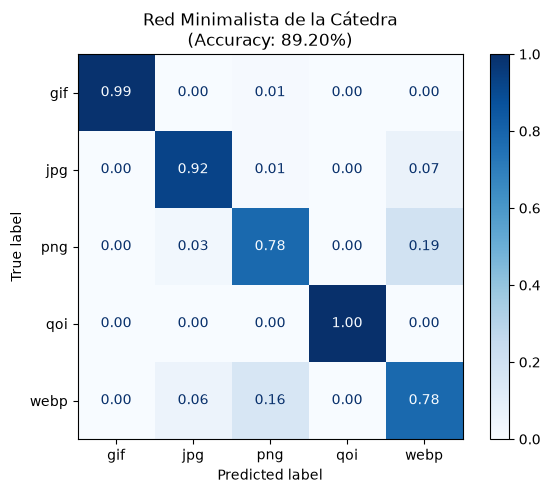

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import to_categorical

# 1. Cargar train completo y test público
print("1. Cargando datos...")
dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
datos_train = dataset[:, :512].astype('float32') / 255.0
etiq_train_txt = np.array([e.strip() for e in dataset[:, 512]])
etiq_train_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e] for e in etiq_train_txt])
trainY_onehot = to_categorical(etiq_train_num, num_classes=5)

publico = np.loadtxt('../dataset/test_publico.csv', delimiter=',', dtype=str)
publico_crudo = publico[:, :512].astype('float32') / 255.0
publicoY_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e.strip()] for e in publico[:, 512]])

# 2. Features y Poda Random Forest
print("2. Extrayendo features y aplicando poda...")
train_feat = enriquecer_features(datos_train)
publico_feat = enriquecer_features(publico_crudo)

bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque.fit(train_feat, etiq_train_num)
indices_top = np.argsort(bosque.feature_importances_)[::-1][:800]

# La cátedra pide explícitamente "Estandarización de las entradas: usar StandardScaler"
scaler = StandardScaler()
trainX_final = scaler.fit_transform(train_feat[:, indices_top])
publicoX_final = scaler.transform(publico_feat[:, indices_top])

# 3. LA ARQUITECTURA MINIMALISTA (Según indicación de la cátedra)
def definir_modelo_catedra():
    modelo = Sequential([
        keras.Input(shape=(800,)),
        Dense(64, activation='swish'),
        Dropout(0.05), # Cátedra: "dropout bajo 5%"
        Dense(32, activation='swish'),
        Dropout(0.05),
        Dense(5, activation='softmax')
    ])
    # Sin BatchNormalization
    modelo.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return modelo

# 4. Entrenamiento y Evaluación K-Fold
print("3. Entrenando red minimalista K-Fold...")
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
probas_totales_publico = np.zeros((len(publicoX_final), 5))

# Cátedra: "Control del overfitting: EarlyStopping"
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

fold_actual = 1
for train_ix, val_ix in kfold.split(trainX_final):
    tX, vX = trainX_final[train_ix], trainX_final[val_ix]
    tY, vY = trainY_onehot[train_ix], trainY_onehot[val_ix]
    
    modelo = definir_modelo_catedra()
    # Usamos batch size estándar
    modelo.fit(tX, tY, epochs=100, batch_size=32, validation_data=(vX, vY),
               callbacks=[early_stop], verbose=0)
    
    probas_totales_publico += modelo.predict(publicoX_final, verbose=0)
    print(f"  Fold {fold_actual}/10 listo")
    fold_actual += 1

# 5. Resultados
print("\n4. Calculando métricas en Test Público...")
probas_promedio = probas_totales_publico / 10.0 
predicciones = np.argmax(probas_promedio, axis=1)

acc = accuracy_score(publicoY_num, predicciones)
print(f"\n---> ACCURACY RED MINIMALISTA: {acc * 100:.2f}% <---")

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
cm = confusion_matrix(publicoY_num, predicciones, normalize='true')
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title(f'Red Minimalista de la Cátedra\n(Accuracy: {acc * 100:.2f}%)')
plt.show()

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import to_categorical

# 1. Cargar datos
dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
datos_completos = dataset[:, :512].astype('float32') / 255.0
etiq_txt = np.array([e.strip() for e in dataset[:, 512]])
etiq_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e] for e in etiq_txt])
etiq_onehot = to_categorical(etiq_num, num_classes=5)

ciego = np.loadtxt('../dataset/clasificacion_test_features.csv', delimiter=',', dtype='float32') / 255.0

# 2. Features, Poda y Scaler
features_completos = enriquecer_features(datos_completos)
ciego_feat_comp = enriquecer_features(ciego)

bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque.fit(features_completos, etiq_num)
indices_top = np.argsort(bosque.feature_importances_)[::-1][:800]

scaler = StandardScaler()
dataX_final = scaler.fit_transform(features_completos[:, indices_top])
ciegoX = scaler.transform(ciego_feat_comp[:, indices_top])

# 3. La Red Minimalista de la Cátedra
def definir_modelo_catedra():
    modelo = Sequential([
        keras.Input(shape=(800,)),
        Dense(64, activation='swish'),
        Dropout(0.05),
        Dense(32, activation='swish'),
        Dropout(0.05),
        Dense(5, activation='softmax')
    ])
    modelo.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return modelo

# 4. Ensamble de la Red Minimalista (10 Folds para estabilizar)
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
probas_totales = np.zeros((len(ciegoX), 5))

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

fold_actual = 1
for train_ix, val_ix in kfold.split(dataX_final):
    tX, vX = dataX_final[train_ix], dataX_final[val_ix]
    tY, vY = etiq_onehot[train_ix], etiq_onehot[val_ix]
    
    modelo = definir_modelo_catedra()
    modelo.fit(tX, tY, epochs=100, batch_size=32, validation_data=(vX, vY),
               callbacks=[early_stop], verbose=0)
    
    probas_totales += modelo.predict(ciegoX, verbose=0)
    fold_actual += 1

# 5. Generar CSV
probas_promedio = probas_totales / 10.0
predicciones_indices = np.argmax(probas_promedio, axis=1)

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
predicciones_texto = [clases[i] for i in predicciones_indices]

pd.DataFrame({'y_pred': predicciones_texto}).to_csv('entrega7.csv', index=False)
print("¡Archivo entrega7.csv generado con éxito!")

¡Archivo entrega7.csv generado con éxito!


Buscando mejoras posibles

1. Cargando datos...
2. Extrayendo features y aplicando poda...
3. Entrenando red minimalista (tanh) K-Fold...
  Fold 1/10 listo
  Fold 2/10 listo
  Fold 3/10 listo
  Fold 4/10 listo
  Fold 5/10 listo
  Fold 6/10 listo
  Fold 7/10 listo
  Fold 8/10 listo
  Fold 9/10 listo
  Fold 10/10 listo

4. Calculando métricas en Test Público...

---> ACCURACY RED MINIMALISTA (TANH): 87.60% <---


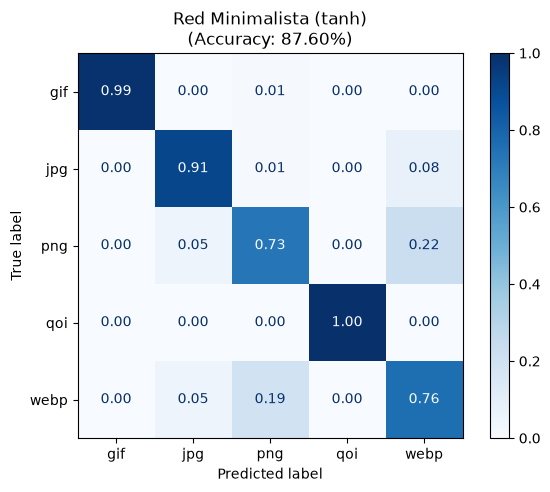

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import to_categorical

# 1. Cargar train completo y test público
print("1. Cargando datos...")
dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
datos_train = dataset[:, :512].astype('float32') / 255.0
etiq_train_txt = np.array([e.strip() for e in dataset[:, 512]])
etiq_train_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e] for e in etiq_train_txt])
trainY_onehot = to_categorical(etiq_train_num, num_classes=5)

publico = np.loadtxt('../dataset/test_publico.csv', delimiter=',', dtype=str)
publico_crudo = publico[:, :512].astype('float32') / 255.0
publicoY_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e.strip()] for e in publico[:, 512]])

# 2. Features y Poda Random Forest
print("2. Extrayendo features y aplicando poda...")
train_feat = enriquecer_features(datos_train)
publico_feat = enriquecer_features(publico_crudo)

bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque.fit(train_feat, etiq_train_num)
indices_top = np.argsort(bosque.feature_importances_)[::-1][:800]

# El StandardScaler es vital para que tanh funcione bien
scaler = StandardScaler()
trainX_final = scaler.fit_transform(train_feat[:, indices_top])
publicoX_final = scaler.transform(publico_feat[:, indices_top])

# 3. LA ARQUITECTURA MINIMALISTA + TANH
def definir_modelo_tanh():
    modelo = Sequential([
        keras.Input(shape=(800,)),
        Dense(64, activation='tanh'),  # Cambio a tanh
        Dropout(0.05),
        Dense(32, activation='tanh'),  # Cambio a tanh
        Dropout(0.05),
        Dense(5, activation='softmax')
    ])
    modelo.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return modelo

# 4. Entrenamiento y Evaluación K-Fold
print("3. Entrenando red minimalista (tanh) K-Fold...")
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
probas_totales_publico = np.zeros((len(publicoX_final), 5))

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

fold_actual = 1
for train_ix, val_ix in kfold.split(trainX_final):
    tX, vX = trainX_final[train_ix], trainX_final[val_ix]
    tY, vY = trainY_onehot[train_ix], trainY_onehot[val_ix]
    
    modelo = definir_modelo_tanh()
    modelo.fit(tX, tY, epochs=100, batch_size=32, validation_data=(vX, vY),
               callbacks=[early_stop], verbose=0)
    
    probas_totales_publico += modelo.predict(publicoX_final, verbose=0)
    print(f"  Fold {fold_actual}/10 listo")
    fold_actual += 1

# 5. Resultados
print("\n4. Calculando métricas en Test Público...")
probas_promedio = probas_totales_publico / 10.0 
predicciones = np.argmax(probas_promedio, axis=1)

acc = accuracy_score(publicoY_num, predicciones)
print(f"\n---> ACCURACY RED MINIMALISTA (TANH): {acc * 100:.2f}% <---")

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
cm = confusion_matrix(publicoY_num, predicciones, normalize='true')
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title(f'Red Minimalista (tanh)\n(Accuracy: {acc * 100:.2f}%)')
plt.show()

Aplicacion de matriz de pearson

1. Cargando datos...
2. Extrayendo features y aplicando poda...
3. Eliminando variables redundantes por correlación...
   -> Variables originales: 800. Variables tras el filtro: 786
4. Entrenando red minimalista K-Fold con variables filtradas...

5. Calculando métricas en Test Público...

---> ACCURACY FINAL (FILTRO CORRELACIÓN): 88.60% <---


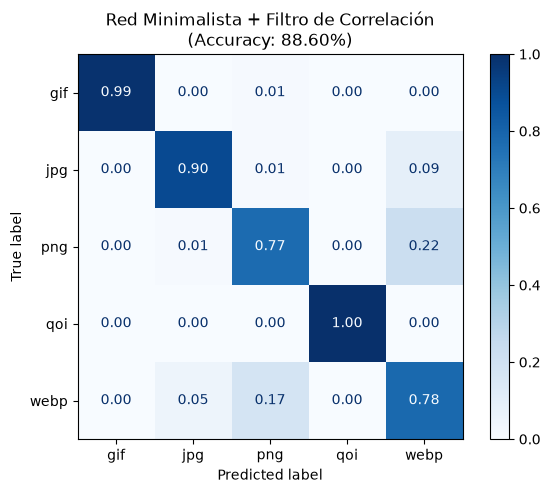

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import to_categorical

# 1. Cargar datos
print("1. Cargando datos...")
dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
datos_train = dataset[:, :512].astype('float32') / 255.0
etiq_train_txt = np.array([e.strip() for e in dataset[:, 512]])
etiq_train_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e] for e in etiq_train_txt])
trainY_onehot = to_categorical(etiq_train_num, num_classes=5)

publico = np.loadtxt('../dataset/test_publico.csv', delimiter=',', dtype=str)
publico_crudo = publico[:, :512].astype('float32') / 255.0
publicoY_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e.strip()] for e in publico[:, 512]])

# 2. Features y Poda Random Forest
print("2. Extrayendo features y aplicando poda...")
train_feat = enriquecer_features(datos_train)
publico_feat = enriquecer_features(publico_crudo)

bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque.fit(train_feat, etiq_train_num)
indices_top = np.argsort(bosque.feature_importances_)[::-1][:800]

train_rf = train_feat[:, indices_top]
publico_rf = publico_feat[:, indices_top]

# 3. FILTRO DE CORRELACIÓN (El truco pendiente de la cátedra)
print("3. Eliminando variables redundantes por correlación...")
df_train = pd.DataFrame(train_rf)
matriz_corr = df_train.corr().abs()
triangulo_sup = matriz_corr.where(np.triu(np.ones(matriz_corr.shape), k=1).astype(bool))
columnas_a_borrar = [columna for columna in triangulo_sup.columns if any(triangulo_sup[columna] > 0.90)]

train_filtrado = df_train.drop(columns=columnas_a_borrar).values
publico_filtrado = pd.DataFrame(publico_rf).drop(columns=columnas_a_borrar).values
print(f"   -> Variables originales: 800. Variables tras el filtro: {train_filtrado.shape[1]}")

scaler = StandardScaler()
trainX_final = scaler.fit_transform(train_filtrado)
publicoX_final = scaler.transform(publico_filtrado)

# 4. Arquitectura Campeona de la Cátedra (Swish)
def definir_modelo_catedra():
    modelo = Sequential([
        keras.Input(shape=(train_filtrado.shape[1],)),
        Dense(64, activation='swish'),
        Dropout(0.05),
        Dense(32, activation='swish'),
        Dropout(0.05),
        Dense(5, activation='softmax')
    ])
    modelo.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return modelo

# 5. Entrenamiento K-Fold
print("4. Entrenando red minimalista K-Fold con variables filtradas...")
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
probas_totales_publico = np.zeros((len(publicoX_final), 5))

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

fold_actual = 1
for train_ix, val_ix in kfold.split(trainX_final):
    tX, vX = trainX_final[train_ix], trainX_final[val_ix]
    tY, vY = trainY_onehot[train_ix], trainY_onehot[val_ix]
    
    modelo = definir_modelo_catedra()
    modelo.fit(tX, tY, epochs=100, batch_size=32, validation_data=(vX, vY),
               callbacks=[early_stop], verbose=0)
    
    probas_totales_publico += modelo.predict(publicoX_final, verbose=0)
    fold_actual += 1

# 6. Evaluación
print("\n5. Calculando métricas en Test Público...")
probas_promedio = probas_totales_publico / 10.0 
predicciones = np.argmax(probas_promedio, axis=1)

acc = accuracy_score(publicoY_num, predicciones)
print(f"\n---> ACCURACY FINAL (FILTRO CORRELACIÓN): {acc * 100:.2f}% <---")

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
cm = confusion_matrix(publicoY_num, predicciones, normalize='true')
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title(f'Red Minimalista + Filtro de Correlación\n(Accuracy: {acc * 100:.2f}%)')
plt.show()

Aplicando label smoothing

1. Cargando datos...
2. Extrayendo features y aplicando poda...
3. Iniciando Ensamblado Conservador (5 Semillas x 10 Folds)...

---> Semilla: 42 <---
  Fold 1/10 completado
  Fold 2/10 completado
  Fold 3/10 completado
  Fold 4/10 completado
  Fold 5/10 completado
  Fold 6/10 completado
  Fold 7/10 completado
  Fold 8/10 completado
  Fold 9/10 completado
  Fold 10/10 completado

---> Semilla: 1 <---
  Fold 1/10 completado
  Fold 2/10 completado
  Fold 3/10 completado
  Fold 4/10 completado
  Fold 5/10 completado
  Fold 6/10 completado
  Fold 7/10 completado
  Fold 8/10 completado
  Fold 9/10 completado
  Fold 10/10 completado

---> Semilla: 123 <---
  Fold 1/10 completado
  Fold 2/10 completado
  Fold 3/10 completado
  Fold 4/10 completado
  Fold 5/10 completado
  Fold 6/10 completado
  Fold 7/10 completado
  Fold 8/10 completado
  Fold 9/10 completado
  Fold 10/10 completado

---> Semilla: 777 <---
  Fold 1/10 completado
  Fold 2/10 completado
  Fold 3/10 completado
  Fold 4/10 comple

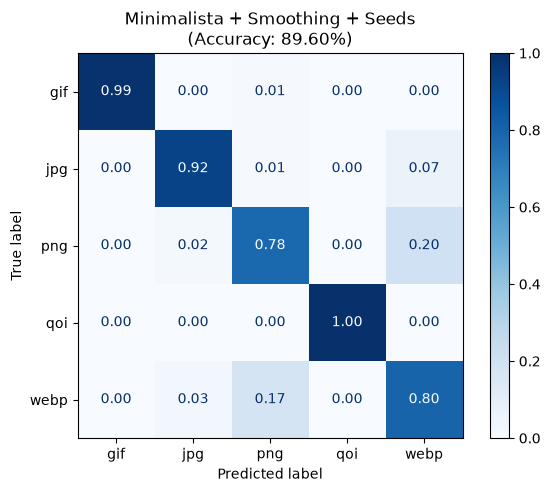

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import to_categorical

# 1. Cargar datos
print("1. Cargando datos...")
dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
datos_train = dataset[:, :512].astype('float32') / 255.0
etiq_train_txt = np.array([e.strip() for e in dataset[:, 512]])
etiq_train_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e] for e in etiq_train_txt])
trainY_onehot = to_categorical(etiq_train_num, num_classes=5)

publico = np.loadtxt('../dataset/test_publico.csv', delimiter=',', dtype=str)
publico_crudo = publico[:, :512].astype('float32') / 255.0
publicoY_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e.strip()] for e in publico[:, 512]])

# 2. Features y Poda
print("2. Extrayendo features y aplicando poda...")
train_feat = enriquecer_features(datos_train)
publico_feat = enriquecer_features(publico_crudo)

bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque.fit(train_feat, etiq_train_num)
indices_top = np.argsort(bosque.feature_importances_)[::-1][:800]

scaler = StandardScaler()
trainX_final = scaler.fit_transform(train_feat[:, indices_top])
publicoX_final = scaler.transform(publico_feat[:, indices_top])

# 3. RED MINIMALISTA CON LABEL SMOOTHING ("Predicciones Conservadoras")
def definir_modelo_conservador():
    modelo = Sequential([
        keras.Input(shape=(800,)),
        Dense(64, activation='swish'),
        Dropout(0.05),
        Dense(32, activation='swish'),
        Dropout(0.05),
        Dense(5, activation='softmax')
    ])
    modelo.compile(
        # Acá está la magia de la cátedra: suavizamos los targets un 10%
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1), 
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return modelo

# 4. SEED BLENDING PURO (Sin tocar pesos)
semillas = [42, 1, 123, 777, 2026]
probas_totales_publico = np.zeros((len(publicoX_final), 5))

print("3. Iniciando Ensamblado Conservador (5 Semillas x 10 Folds)...")

for seed in semillas:
    print(f"\n---> Semilla: {seed} <---")
    keras.utils.set_random_seed(seed)
    
    kfold = KFold(n_splits=10, shuffle=True, random_state=seed)
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
    
    fold_actual = 1
    for train_ix, val_ix in kfold.split(trainX_final):
        tX, vX = trainX_final[train_ix], trainX_final[val_ix]
        tY, vY = trainY_onehot[train_ix], trainY_onehot[val_ix]
        
        modelo = definir_modelo_conservador()
        modelo.fit(tX, tY, epochs=120, batch_size=32, validation_data=(vX, vY),
                   callbacks=[early_stop], verbose=0)
        
        probas_totales_publico += modelo.predict(publicoX_final, verbose=0)
        print(f"  Fold {fold_actual}/10 completado")
        fold_actual += 1

# 5. Evaluación Final
print("\n4. Calculando métricas...")
probas_promedio = probas_totales_publico / 50.0 
predicciones = np.argmax(probas_promedio, axis=1)

acc = accuracy_score(publicoY_num, predicciones)
print(f"\n---> ACCURACY FINAL (MINIMALISTA + SMOOTHING + SEEDS): {acc * 100:.2f}% <---")

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
cm = confusion_matrix(publicoY_num, predicciones, normalize='true')
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title(f'Minimalista + Smoothing + Seeds\n(Accuracy: {acc * 100:.2f}%)')
plt.show()

Compactando features

1. Cargando datos crudos...
2. Extrayendo features estadísticas limpias...
   -> Dimensiones finales: 88 variables (sin sobrecargar el modelo)
3. Evaluando en 10 Folds...
  Fold 1/10 completado
  Fold 2/10 completado
  Fold 3/10 completado
  Fold 4/10 completado
  Fold 5/10 completado
  Fold 6/10 completado
  Fold 7/10 completado
  Fold 8/10 completado
  Fold 9/10 completado
  Fold 10/10 completado

---> ACCURACY FEATURES COMPACTAS: 75.00% <---


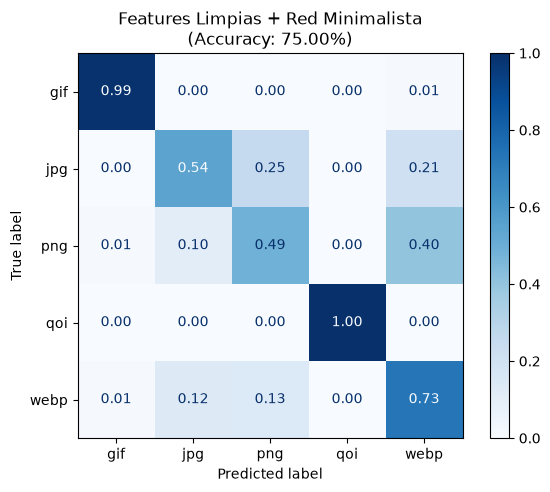

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import to_categorical

# 1. Feature Engineering Compacto (como los punteros)
def extraer_features_compactas(X_raw):
    # X_raw viene normalizado entre 0 y 1 o de 0 a 255; trabajamos con bytes 0-255
    X_bytes = (X_raw * 255.0).astype(np.float32)
    N = X_bytes.shape[0]
    feats = []
    
    for i in range(N):
        fila = X_bytes[i]
        f_i = []
        
        # A. Primeros 32 bytes directos (magic numbers / firmas de header)
        f_i.extend(fila[:32] / 255.0)
        
        # B. Estadísticas globales básicas
        f_i.append(np.mean(fila))
        f_i.append(np.std(fila))
        f_i.append(np.median(fila))
        f_i.append(np.var(fila))
        f_i.append(np.min(fila))
        f_i.append(np.max(fila))
        f_i.append(float(skew(fila)))
        f_i.append(float(kurtosis(fila)))
        
        # C. Histograma básico (32 bins de frecuencias de byte)
        hist, _ = np.histogram(fila, bins=32, range=(0, 256), density=True)
        f_i.extend(hist)
        
        # D. Estadísticas en 4 bloques de 128 bytes (para capturar transición de compresión)
        for b in range(4):
            bloque = fila[b*128 : (b+1)*128]
            f_i.append(np.mean(bloque))
            f_i.append(np.std(bloque))
            f_i.append(np.median(bloque))
            # Ratio de bytes cero en el bloque (típico de headers fijos vs payload comprimido)
            f_i.append(np.sum(bloque == 0) / 128.0)
            
        feats.append(f_i)
        
    return np.array(feats, dtype=np.float32)

# 2. Cargar datos
print("1. Cargando datos crudos...")
dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
datos_train = dataset[:, :512].astype('float32') / 255.0
etiq_train_txt = np.array([e.strip() for e in dataset[:, 512]])
etiq_train_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e] for e in etiq_train_txt])
trainY_onehot = to_categorical(etiq_train_num, num_classes=5)

publico = np.loadtxt('../dataset/test_publico.csv', delimiter=',', dtype=str)
publico_crudo = publico[:, :512].astype('float32') / 255.0
publicoY_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e.strip()] for e in publico[:, 512]])

# 3. Extracción compacta SIN poda de Random Forest
print("2. Extrayendo features estadísticas limpias...")
train_feat = extraer_features_compactas(datos_train)
publico_feat = extraer_features_compactas(publico_crudo)
print(f"   -> Dimensiones finales: {train_feat.shape[1]} variables (sin sobrecargar el modelo)")

scaler = StandardScaler()
trainX_final = scaler.fit_transform(train_feat)
publicoX_final = scaler.transform(publico_feat)

# 4. Red Minimalista Swish (la que la cátedra y tus pruebas confirmaron)
def definir_modelo_limpio():
    modelo = Sequential([
        keras.Input(shape=(trainX_final.shape[1],)),
        Dense(64, activation='swish'),
        Dropout(0.05),
        Dense(32, activation='swish'),
        Dropout(0.05),
        Dense(5, activation='softmax')
    ])
    modelo.compile(
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return modelo

# 5. K-Fold de 10 cortes
print("3. Evaluando en 10 Folds...")
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
probas_totales = np.zeros((len(publicoX_final), 5))

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

for fold, (train_ix, val_ix) in enumerate(kfold.split(trainX_final), 1):
    tX, vX = trainX_final[train_ix], trainX_final[val_ix]
    tY, vY = trainY_onehot[train_ix], trainY_onehot[val_ix]
    
    m = definir_modelo_limpio()
    m.fit(tX, tY, epochs=120, batch_size=32, validation_data=(vX, vY),
          callbacks=[early_stop], verbose=0)
    probas_totales += m.predict(publicoX_final, verbose=0)
    print(f"  Fold {fold}/10 completado")

# 6. Métricas finales
probas_promedio = probas_totales / 10.0
predicciones = np.argmax(probas_promedio, axis=1)

acc = accuracy_score(publicoY_num, predicciones)
print(f"\n---> ACCURACY FEATURES COMPACTAS: {acc * 100:.2f}% <---")

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
cm = confusion_matrix(publicoY_num, predicciones, normalize='true')
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title(f'Features Limpias + Red Minimalista\n(Accuracy: {acc * 100:.2f}%)')
plt.show()

In [27]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 3.7/101.7 MB 36.3 MB/s eta 0:00:03
   ---- ----------------------------------- 11.8/101.7 MB 36.9 MB/s eta 0:00:03
   ------ --------------------------------- 17.0/101.7 MB 32.5 MB/s eta 0:00:03
   --------- ------------------------------ 23.1/101.7 MB 33.1 MB/s eta 0:00:03
   ----------- ---------------------------- 29.6/101.7 MB 31.8 MB/s eta 0:00:03
   ------------- -------------------------- 34.9/101.7 MB 30.8 MB/s eta 0:00:03
   ---------------- ----------------------- 42.5/101.7 MB 31.8 MB/s eta 0:00:02
   ------------------- -------------------- 49.5/101.7 MB 32.5 MB/s eta 0:00:02
   --------------------- ------------------ 55.1/101.7 MB 31.6 MB/s eta 0:00:02
   ------------------------ --------------- 62.9/101.7 MB 32.1 MB/s eta 0:00:02
   --------------------------- ------------ 70.8/101.7 MB 32.9 MB/s eta 0:00:01
   ------------------------------ --------- 78.4/1

1. Cargando datos...
2. Extrayendo features y aplicando poda...
3. Entrenando Ensamble Heterogéneo (Red + XGBoost + SVC)...


c:\facu\ia\red-neuronal-regresion-IA-2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  Fold 1/10 listo (Votación completada)


c:\facu\ia\red-neuronal-regresion-IA-2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  Fold 2/10 listo (Votación completada)


...

  Fold 8/10 listo (Votación completada)


c:\facu\ia\red-neuronal-regresion-IA-2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  Fold 9/10 listo (Votación completada)


c:\facu\ia\red-neuronal-regresion-IA-2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  Fold 10/10 listo (Votación completada)

4. Calculando métricas en Test Público...

---> ACCURACY ENSAMBLE HETEROGÉNEO: 93.00% <---


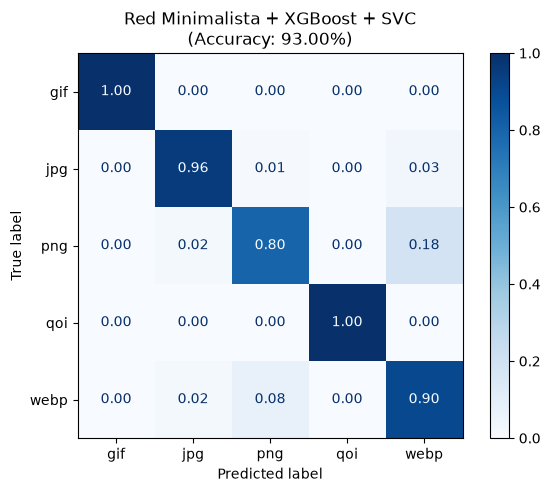

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import to_categorical

# 1. Cargar datos
print("1. Cargando datos...")
dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
datos_train = dataset[:, :512].astype('float32') / 255.0
etiq_train_txt = np.array([e.strip() for e in dataset[:, 512]])
etiq_train_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e] for e in etiq_train_txt])
trainY_onehot = to_categorical(etiq_train_num, num_classes=5)

publico = np.loadtxt('../dataset/test_publico.csv', delimiter=',', dtype=str)
publico_crudo = publico[:, :512].astype('float32') / 255.0
publicoY_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e.strip()] for e in publico[:, 512]])

# 2. Features y Poda Random Forest (La base que funciona)
print("2. Extrayendo features y aplicando poda...")
train_feat = enriquecer_features(datos_train)
publico_feat = enriquecer_features(publico_crudo)

bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque.fit(train_feat, etiq_train_num)
indices_top = np.argsort(bosque.feature_importances_)[::-1][:800]

scaler = StandardScaler()
trainX_final = scaler.fit_transform(train_feat[:, indices_top])
publicoX_final = scaler.transform(publico_feat[:, indices_top])

# 3. Definición de los 3 Modelos
def definir_red_neuronal():
    modelo = Sequential([
        keras.Input(shape=(800,)),
        Dense(64, activation='swish'),
        Dropout(0.05),
        Dense(32, activation='swish'),
        Dropout(0.05),
        Dense(5, activation='softmax')
    ])
    modelo.compile(
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return modelo

# 4. K-Fold con Soft Voting
print("3. Entrenando Ensamble Heterogéneo (Red + XGBoost + SVC)...")
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

probas_totales_publico = np.zeros((len(publicoX_final), 5))
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

fold_actual = 1
for train_ix, val_ix in kfold.split(trainX_final):
    tX, vX = trainX_final[train_ix], trainX_final[val_ix]
    tY, vY = trainY_onehot[train_ix], trainY_onehot[val_ix]
    tY_num = etiq_train_num[train_ix] # XGBoost y SVC usan etiquetas numéricas
    
    # Modelo 1: Red Neuronal
    nn = definir_red_neuronal()
    nn.fit(tX, tY, epochs=120, batch_size=32, validation_data=(vX, vY), callbacks=[early_stop], verbose=0)
    probas_nn = nn.predict(publicoX_final, verbose=0)
    
    # Modelo 2: XGBoost
    xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
    xgb.fit(tX, tY_num)
    probas_xgb = xgb.predict_proba(publicoX_final)
    
    # Modelo 3: Support Vector Classifier
    svc = SVC(probability=True, kernel='rbf', C=1.0, random_state=42)
    svc.fit(tX, tY_num)
    probas_svc = svc.predict_proba(publicoX_final)
    
    # Soft Voting: Promediamos las probabilidades de los 3 modelos
    probas_fold = (probas_nn + probas_xgb + probas_svc) / 3.0
    probas_totales_publico += probas_fold
    
    print(f"  Fold {fold_actual}/10 listo (Votación completada)")
    fold_actual += 1

# 5. Evaluación Final
print("\n4. Calculando métricas en Test Público...")
probas_promedio = probas_totales_publico / 10.0
predicciones = np.argmax(probas_promedio, axis=1)

acc = accuracy_score(publicoY_num, predicciones)
print(f"\n---> ACCURACY ENSAMBLE HETEROGÉNEO: {acc * 100:.2f}% <---")

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
cm = confusion_matrix(publicoY_num, predicciones, normalize='true')
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title(f'Red Minimalista + XGBoost + SVC\n(Accuracy: {acc * 100:.2f}%)')
plt.show()

Entrega 8


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import to_categorical

# 1. Cargar datos de entrenamiento completos
print("1. Cargando datos...")
dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
datos_completos = dataset[:, :512].astype('float32') / 255.0
etiq_txt = np.array([e.strip() for e in dataset[:, 512]])
etiq_num = np.array([{'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[e] for e in etiq_txt])
etiq_onehot = to_categorical(etiq_num, num_classes=5)

# Cargar el test ciego oficial
ciego = np.loadtxt('../dataset/clasificacion_test_features.csv', delimiter=',', dtype='float32') / 255.0

# 2. Features y Poda Random Forest
print("2. Extrayendo features...")
# Asumimos que tu función enriquecer_features ya está cargada en memoria
features_completos = enriquecer_features(datos_completos)
ciego_feat_comp = enriquecer_features(ciego)

print("3. Aplicando poda con Random Forest (800 features)...")
bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque.fit(features_completos, etiq_num)
indices_top = np.argsort(bosque.feature_importances_)[::-1][:800]

scaler = StandardScaler()
dataX_final = scaler.fit_transform(features_completos[:, indices_top])
ciegoX_final = scaler.transform(ciego_feat_comp[:, indices_top])

# 3. Definir Red Minimalista
def definir_red_neuronal():
    modelo = Sequential([
        keras.Input(shape=(800,)),
        Dense(64, activation='swish'),
        Dropout(0.05),
        Dense(32, activation='swish'),
        Dropout(0.05),
        Dense(5, activation='softmax')
    ])
    modelo.compile(
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return modelo

# 4. K-Fold con Soft Voting sobre el Test Ciego
print("4. Entrenando Ensamble Heterogéneo (10 Folds)... Esto puede tardar un poco.")
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

probas_totales_ciego = np.zeros((len(ciegoX_final), 5))
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

fold_actual = 1
for train_ix, val_ix in kfold.split(dataX_final):
    # LÍNEA CORREGIDA PARA EVITAR EL ERROR DE 'data' SUELTO
    tX, vX = dataX_final[train_ix], dataX_final[val_ix]
    tY_onehot, vY_onehot = etiq_onehot[train_ix], etiq_onehot[val_ix]
    tY_num = etiq_num[train_ix] 
    
    # Modelo 1: Red Neuronal
    nn = definir_red_neuronal()
    nn.fit(tX, tY_onehot, epochs=120, batch_size=32, validation_data=(vX, vY_onehot), callbacks=[early_stop], verbose=0)
    probas_nn = nn.predict(ciegoX_final, verbose=0)
    
    # Modelo 2: XGBoost
    xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
    xgb.fit(tX, tY_num)
    probas_xgb = xgb.predict_proba(ciegoX_final)
    
    # Modelo 3: SVC
    svc = SVC(probability=True, kernel='rbf', C=1.0, random_state=42)
    svc.fit(tX, tY_num)
    probas_svc = svc.predict_proba(ciegoX_final)
    
    # Soft Voting
    probas_fold = (probas_nn + probas_xgb + probas_svc) / 3.0
    probas_totales_ciego += probas_fold
    
    print(f"  Fold {fold_actual}/10 completado")
    fold_actual += 1

# 5. Generar CSV Final
print("\n5. Promediando votos y generando CSV...")
probas_promedio = probas_totales_ciego / 10.0
predicciones_indices = np.argmax(probas_promedio, axis=1)

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
predicciones_texto = [clases[i] for i in predicciones_indices]

pd.DataFrame({'y_pred': predicciones_texto}).to_csv('entrega8.csv', index=False)
print("¡Archivo entrega_definitiva_ensamble.csv generado con éxito! Listo para subir.")

1. Cargando datos...
2. Extrayendo features...
3. Aplicando poda con Random Forest (800 features)...
4. Entrenando Ensamble Heterogéneo (10 Folds)... Esto puede tardar un poco.


c:\facu\ia\red-neuronal-regresion-IA-2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  Fold 1/10 completado


c:\facu\ia\red-neuronal-regresion-IA-2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  Fold 2/10 completado


...

  Fold 8/10 completado


c:\facu\ia\red-neuronal-regresion-IA-2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  Fold 9/10 completado


c:\facu\ia\red-neuronal-regresion-IA-2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  Fold 10/10 completado

5. Promediando votos y generando CSV...
¡Archivo entrega_definitiva_ensamble.csv generado con éxito! Listo para subir.
